In [1]:
import jax.random as jrandom
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from pymob.simulation import SimulationBase
from pymob.solvers.diffrax import UDESolver
from pymob.sim.config import Param
import diffrax
import jax.random as jr
import jax.nn as jnn
import jax
from typing import Callable
from pymob.utils.UDE import UDEBase
from matplotlib import rcParams
import arviz as az

# jax.config.update('jax_enable_x64', True)

c:\Users\Markus\anaconda3\envs\pymob3\Lib\site-packages\sympy2jax\sympy_module.py:290: UserWarning: `equinox.static_field` is deprecated in favour of `equinox.field(static=True)`
  has_extra_funcs: bool = eqx.static_field()


Method to create artificial data

In [2]:
def _get_data(ts, theta, max, min, noisiness, *, key):
    """
    Returns a single time series (evaluated at the time points defined by ts) of the 
    Lotka-Volterra model with some normally-distributed noise. Initial conditions for 
    prey and predator are both chosen randomly from the range [min, max].

    Parameters
    ----------
    ts : jax.ArrayImpl
        An array containing all the time points the timeseries should be evaluated for.
    theta : list
        A list of four floats representing the parameters of the Lotka Volterra model
        [alpha, beta, gamma, delta].
    max : float
        Maximum value for the initial prey and predator values (before adding noise).
    min : float
        Minimum value for the initial prey and predator values (before adding noise).
    noisiness : float
        Scale of the normal distribution the noise is drawn from. If noisiness == 0,
        no noise is added.
    key : jax.ArrayImpl, optional
        A key used to make stochastic processes (in this case the noise values drawn 
        from a normal distribution) reproducible. If no key is provided, noise may
        differ between runs.

    Returns:
    --------
    jax.ArrayImpl
        An array containing a noisy Lotka Volterra time series, evaluated at time
        points ts.
    """
    
    y0 = jr.uniform(key, (2,), minval=min, maxval=max)

    def f(t, y, args):
        dXdt = theta[0] * y[0] - theta[1] * y[0] * y[1]
        dYdt = theta[2] * y[0] * y[1] - theta[3] * y[1]
        return jnp.stack([dXdt, dYdt], axis=-1)

    solver = diffrax.Tsit5()
    dt0 = 0.1
    saveat = diffrax.SaveAt(ts=ts)
    sol = diffrax.diffeqsolve(
        diffrax.ODETerm(f), solver, ts[0], ts[-1], dt0, y0, saveat=saveat
    )
    ys = sol.ys
    noise = jr.normal(key=key, shape=(len(ts), 2))
    ys += noisiness * noise
    return jnp.greater(ys, jnp.zeros(ys.shape)) * ys + 1e-8

def get_data(dataset_size, theta, max, min, t_end, datapoints, noisiness, *, key):
    """
    Returns multiple time series (evaluated at the time points defined by ts) of the 
    Lotka-Volterra model with some normally-distributed noise and different initial 
    conditions for prey and predator chosen randomly from the range [min, max].

    Parameters
    ----------
    dataset_size : int
        The amount of generated time series.
    theta : list
        A list of four floats representing the parameters of the Lotka Volterra model
        [alpha, beta, gamma, delta].
    max : float
        Maximum value for the initial prey and predator values (before adding noise).
    min : float
        Minimum value for the initial prey and predator values (before adding noise).
    t_end : float
        The last point in time that the time series are supposed to contain.
    datapoints : int
        The amount of evenly-spaced datapoints each time series is supposed to contain.
    noisiness : float
        Scale of the normal distribution the noise is drawn from. If noisiness == 0,
        no noise is added.
    key : jax.Array
        A key used to make stochastic processes (in this case the noise values drawn 
        from a normal distribution) reproducible. If no key is provided, noise may
        differ between runs.

    Returns:
    --------
    jax.ArrayImpl
        An array containing multiple noisy Lotka Volterra time series, evaluated at time
        points ts.
    """

    ts = jnp.linspace(0, t_end, datapoints)
    key = jr.split(key, dataset_size)
    ys = jax.vmap(lambda key: _get_data(ts, theta, max, min, noisiness, key=key))(key)
    return ts, ys

### Model for Figure 8 (exploding gradients)

#### Variant 1: Run inference process

Model formulation

In [3]:
class Func(UDEBase):

    mlp_depth: int = 3
    mlp_width: int = 3
    mlp_in_size: int = 2
    mlp_out_size: int = 2
    mlp_activation: Callable = staticmethod(jnn.softplus)
    mlp_final_activation: Callable = staticmethod(jnn.identity)

    alpha: jax.Array
    delta: jax.Array
    
    @staticmethod
    def model(t, y, mlp, alpha, delta, ):
        prey, predator = y
        
        dprey_dt_ode = alpha * prey 
        dpredator_dt_ode = - delta * predator
        dprey_dt_nn, dpredator_dt_nn = mlp(y) * jnp.array([jnp.tanh(prey).astype(float), jnp.tanh(predator).astype(float)])

        dprey_dt = dprey_dt_ode + dprey_dt_nn
        dpredator_dt = dpredator_dt_ode + dpredator_dt_nn

        return dprey_dt, dpredator_dt
    
    @staticmethod
    def loss(y_obs, y_pred):
        return (y_obs - y_pred)**2

Create a simulation with n=50 data batches

C:\Users\Markus\pymob\pymob\simulation.py:309: UserWarning: `sim.config.data_structure.prey = Datavariable(dimensions=['batch_id', 'time'] min=0.3567415475845337 max=7.36574125289917 observed=True dimensions_evaluator=None)` has been assumed from `sim.observations`. If the order of the dimensions should be different, specify `sim.config.data_structure.prey = DataVariable(dimensions=[...], ...)` manually.
  warnings.warn(
C:\Users\Markus\pymob\pymob\simulation.py:309: UserWarning: `sim.config.data_structure.predator = Datavariable(dimensions=['batch_id', 'time'] min=0.13458672165870667 max=5.283197402954102 observed=True dimensions_evaluator=None)` has been assumed from `sim.observations`. If the order of the dimensions should be different, specify `sim.config.data_structure.predator = DataVariable(dimensions=[...], ...)` manually.
  warnings.warn(
C:\Users\Markus\pymob\pymob\simulation.py:579: UserWarning: The number of ODE states was not specified in the config file [simulation] > 'n_

MinMaxScaler(variable=prey, min=0.3567415475845337, max=7.36574125289917)
MinMaxScaler(variable=predator, min=0.13458672165870667, max=5.283197402954102)


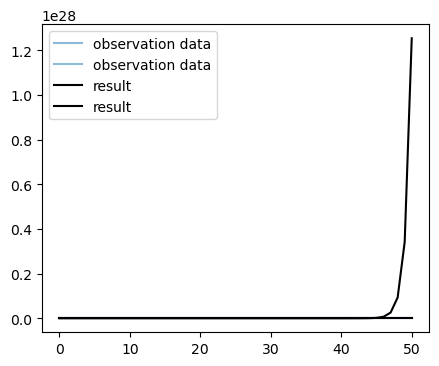

In [ ]:
n = 50

# Initialize the simulation object
sim = SimulationBase()

# Configure the case study
sim.config.case_study.name = "lotka_volterra_UDE_case_study"
sim.config.case_study.scenario = "UDETest"

key = jrandom.PRNGKey(5678)
data_key, model_key, optim_key = jrandom.split(key, 3)

# Add the model to the simulation
sim.model = Func({"alpha":jnp.array(1.3), "delta":jnp.array(1.8)},key=model_key)

# Define a solver
sim.solver = UDESolver

ts,ys = get_data(n, [1.3,0.9,0.8,1.8], 5, 1, 50, 51, 0.0, key=jr.PRNGKey(0))

# Create an xArray dataset containing the artificial data
datasets = jnp.linspace(0,n-1,n)

test_data1 = xr.DataArray(ys[:,:,0], coords={"batch_id": datasets, "time": ts}).to_dataset(name="prey")
test_data2 = xr.DataArray(ys[:,:,1], coords={"batch_id": datasets, "time": ts}).to_dataset(name="predator")
test_data = xr.merge([test_data1, test_data2])

# Add our dataset to the simulation
sim.observations = test_data

# Add the initial condition to the simulation
sim.model_parameters["y0"] = sim.observations.sel(time = 0).drop_vars("time")

sim.config.model_parameters.alpha = Param(value=1.3, free=False)
sim.config.model_parameters.delta = Param(value=1.8, free=True)
sim.config.model_parameters.delta.prior = "uniform(loc=1.0,scale=2.0)"

sim.model_parameters["parameters"] = sim.config.model_parameters.value_dict

# Create an xArray dataset containing the external input data
# xin = xr.DataArray(np.zeros(201), coords={"time": ts}).to_dataset(name="x_in")

# Add external inputs to the simulation
# sim.model_parameters["x_in"] = xin

# sim.config.jaxsolver.max_steps = 10000
sim.config.jaxsolver.throw_exception = False

# Put everything in place for running the simulation
sim.dispatch_constructor()

# Create an evaluator
evaluator = sim.dispatch()

Initialize inferer

In [5]:
sim.config.inference_optax.MLP_weight_dist = "normal()"
sim.config.inference_optax.MLP_bias_dist = "normal()"
sim.config.inference_optax.batch_size = 20
sim.config.inference_optax.data_split = 0.8
sim.config.inference_optax.multiple_runs_target = 10
sim.config.inference_optax.multiple_runs_limit = 20
sim.config.inference_optax.time_limit = 600

sim.config.inference_optax.length_strategy = [0.1,1]
sim.config.inference_optax.lr_strategy = 0.01
sim.config.inference_optax.steps_strategy = [1000, 1000]
sim.config.inference_optax.clip_strategy = 0
sim.config.inference_optax.indepth = "partial"

sim.set_inferer("optax")

# grad_loss_debug(model, ts, ys, 5, x_in, loss_func)
# self.simulation.evaluator._solver.standalone_solver(model, ts, ys[0,0], x_in)

Runs inferer (implementation using the `standalone_solver` workaround)

In [8]:
sim.inferer.run(optim_key)

10 of 10 runs completed: 100%|██████████| 20000/20000 [32:31<00:00, 10.25it/s, 10 unsuccessful runs so far] 



run number	successful?	loss

run 1		no		---
run 2		yes		4.610127925872803
run 3		no		---
run 4		yes		2.0429635047912598
run 5		no		---
run 6		yes		4.608774185180664
run 7		no		---
run 8		no		---
run 9		no		---
run 10		yes		2.185871124267578
run 11		yes		5.606475830078125
run 12		no		---
run 13		yes		4.615886688232422
run 14		yes		5.625264644622803
run 15		no		---
run 16		yes		5.566476345062256
run 17		yes		5.603414535522461
run 18		no		---
run 19		no		---
run 20		yes		4.607729434967041


Save results

In [10]:
sim.inferer.store_loss_evolution("failed_training/exploding_gradients.nc")

Plot loss evolution

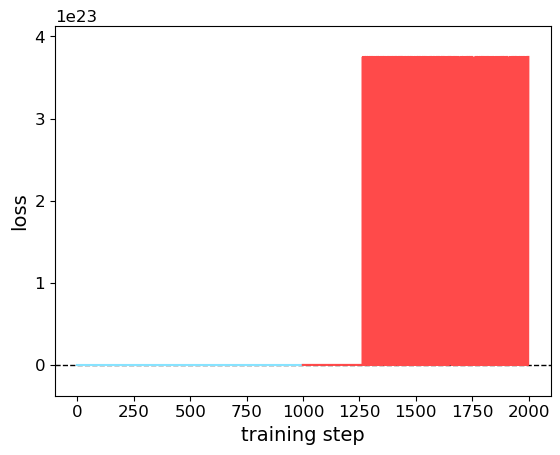

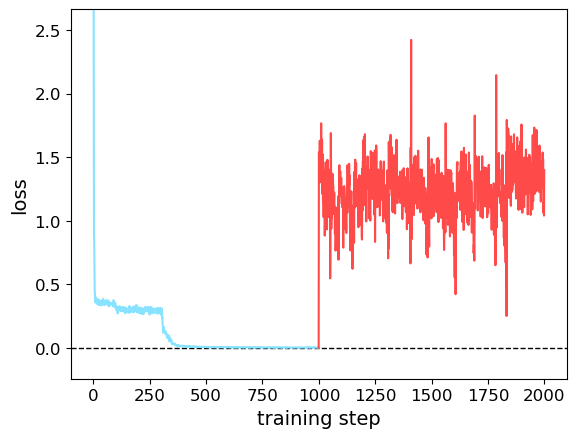

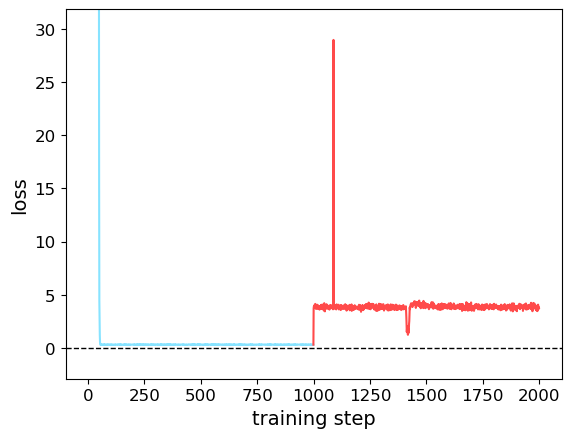

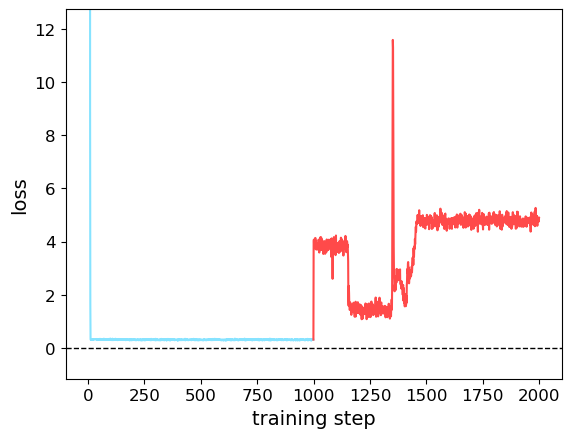

In [86]:
rcParams["font.size"] = 12

for no_run in [2,4,6,16]:

    fig, ax = plt.subplots()
    ax.axhline(0, linestyle= "--", linewidth=1,c="#000000")
    ax.plot(jnp.arange(0,1000), sim.inferer.lossev.sel(run=no_run).losses.values[0:1000], c="#87E3FF", label="using first 10% of dataset")
    ax.plot(jnp.arange(999,2000), sim.inferer.lossev.sel(run=no_run).losses.values[999:2000], c="#FF4A4A", label="using full dataset")
    ax.set_xlabel("training step", fontsize=14)
    ax.set_ylabel("loss", fontsize=14)
    ax.set_ylim(-0.1 * max(sim.inferer.lossev.sel(run=no_run).losses.values[999:2000]), 1.1*max(sim.inferer.lossev.sel(run=no_run).losses.values[999:2000]))
    plt.savefig(f"failed_training/exploding_gradients_run_{str(no_run)}_dyn_intercept.png")

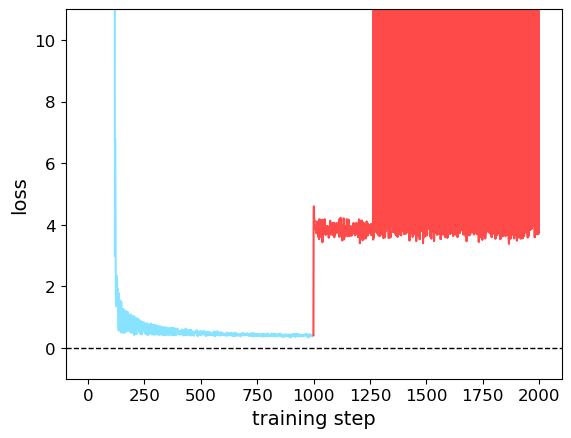

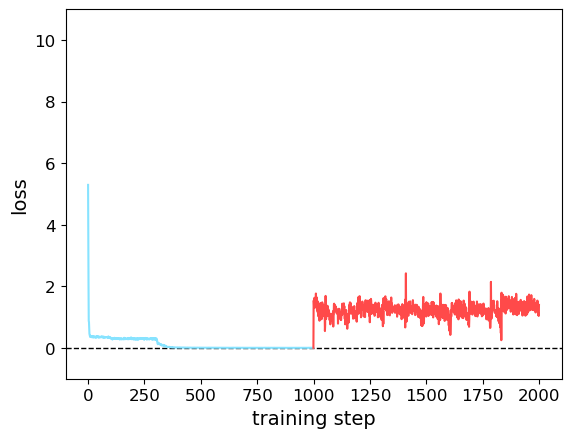

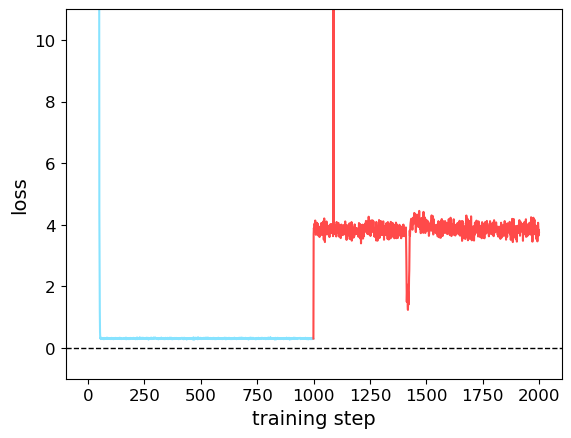

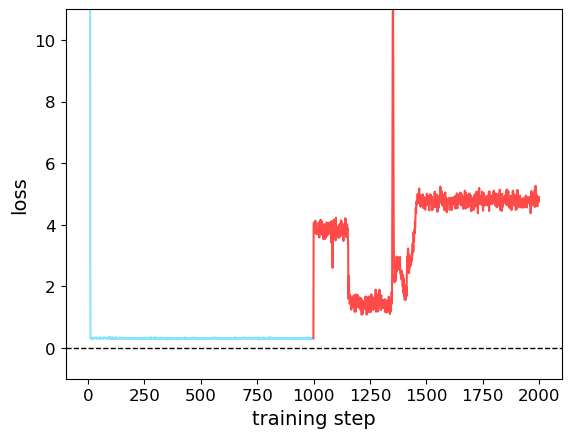

In [87]:
rcParams["font.size"] = 12

for no_run in [2,4,6,16]:

    fig, ax = plt.subplots()
    ax.axhline(0, linestyle= "--", linewidth=1,c="#000000")
    ax.plot(jnp.arange(0,1000), sim.inferer.lossev.sel(run=no_run).losses.values[0:1000], c="#87E3FF", label="using first 10% of dataset")
    ax.plot(jnp.arange(999,2000), sim.inferer.lossev.sel(run=no_run).losses.values[999:2000], c="#FF4A4A", label="using full dataset")
    ax.set_xlabel("training step", fontsize=14)
    ax.set_ylabel("loss", fontsize=14)
    ax.set_ylim(-1,11)
    plt.savefig(f"failed_training/exploding_gradients_run_{str(no_run)}.png")

#### Variant 2: Load data

In [ ]:
lossev = xr.open_dataset(f"failed_training/exploding_gradients.nc")

Plot loss evolution

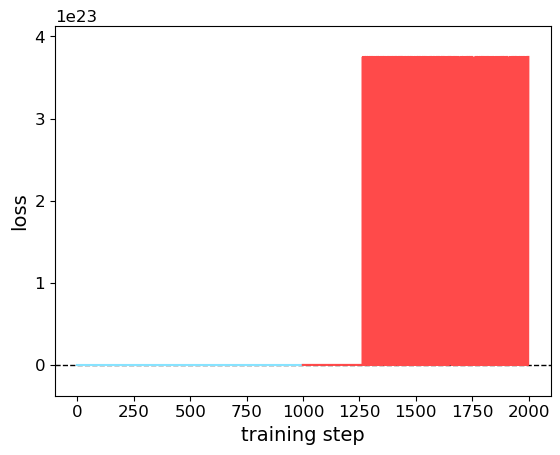

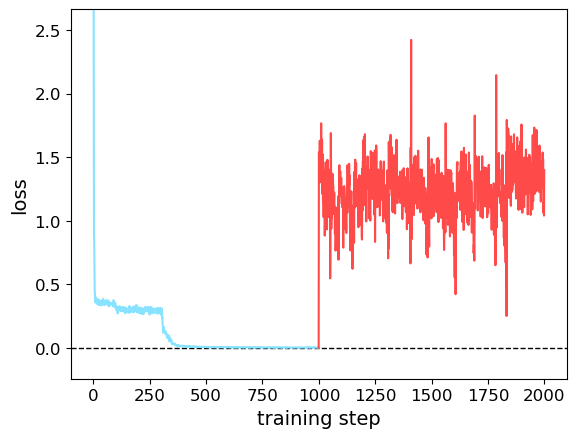

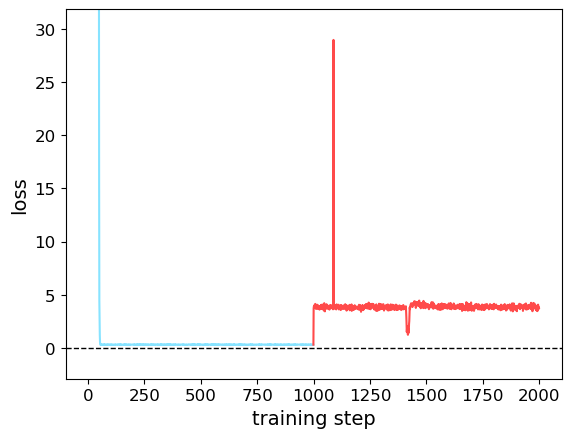

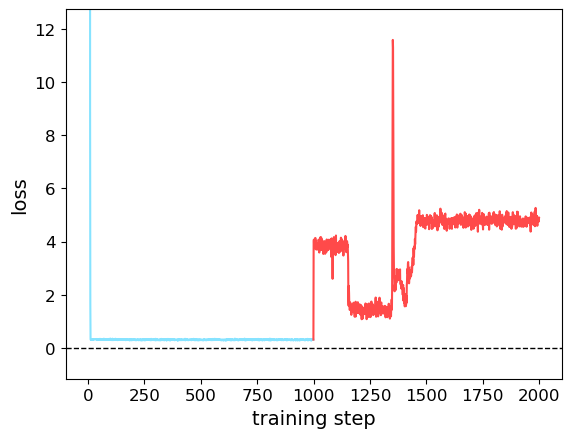

In [ ]:
rcParams["font.size"] = 12

for no_run in [2,4,6,16]:

    fig, ax = plt.subplots()
    ax.axhline(0, linestyle= "--", linewidth=1,c="#000000")
    ax.plot(jnp.arange(0,1000), lossev.sel(run=no_run).losses.values[0:1000], c="#87E3FF", label="using first 10% of dataset")
    ax.plot(jnp.arange(999,2000), lossev.sel(run=no_run).losses.values[999:2000], c="#FF4A4A", label="using full dataset")
    ax.set_xlabel("training step", fontsize=14)
    ax.set_ylabel("loss", fontsize=14)
    ax.set_ylim(-0.1 * max(lossev.sel(run=no_run).losses.values[999:2000]), 1.1*max(lossev.sel(run=no_run).losses.values[999:2000]))
    plt.savefig(f"failed_training/exploding_gradients_run_{str(no_run)}_dyn_intercept.png")

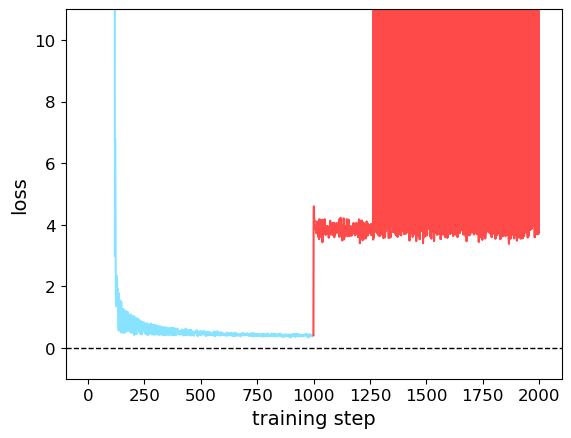

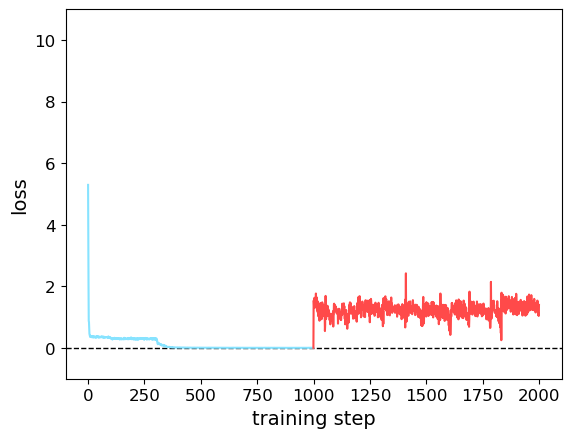

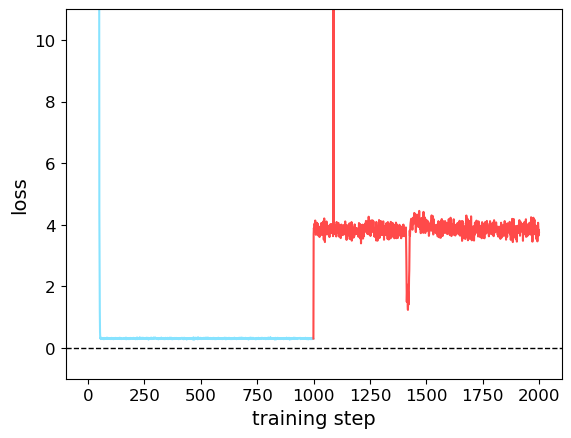

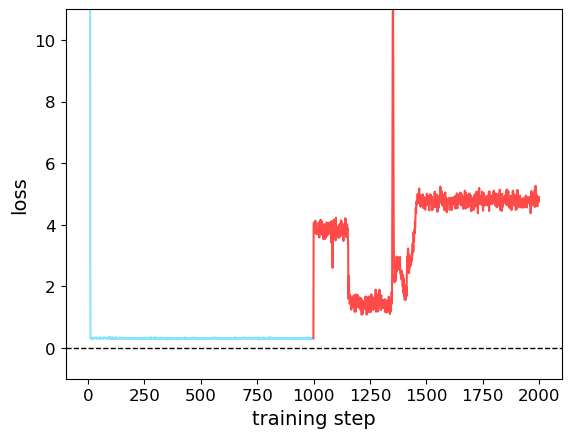

In [ ]:
rcParams["font.size"] = 12

for no_run in [2,4,6,16]:

    fig, ax = plt.subplots()
    ax.axhline(0, linestyle= "--", linewidth=1,c="#000000")
    ax.plot(jnp.arange(0,1000), lossev.sel(run=no_run).losses.values[0:1000], c="#87E3FF", label="using first 10% of dataset")
    ax.plot(jnp.arange(999,2000), lossev.sel(run=no_run).losses.values[999:2000], c="#FF4A4A", label="using full dataset")
    ax.set_xlabel("training step", fontsize=14)
    ax.set_ylabel("loss", fontsize=14)
    ax.set_ylim(-1,11)
    plt.savefig(f"failed_training/exploding_gradients_run_{str(no_run)}.png")

### Model for Figure 9 (negative values)

#### Variant 1: Run inference process

Model formulation

In [11]:
class Func(UDEBase):

    mlp_depth: int = 3
    mlp_width: int = 3
    mlp_in_size: int = 2
    mlp_out_size: int = 2
    mlp_activation: Callable = staticmethod(jnn.softplus)
    mlp_final_activation: Callable = staticmethod(jnn.identity)

    alpha: jax.Array
    delta: jax.Array
    
    @staticmethod
    def model(t, y, mlp, alpha, delta, ):
        prey, predator = y
        
        dprey_dt_ode = alpha * prey 
        dpredator_dt_ode = - delta * predator
        dprey_dt_nn, dpredator_dt_nn = mlp(y)

        dprey_dt = dprey_dt_ode + dprey_dt_nn
        dpredator_dt = dpredator_dt_ode + dpredator_dt_nn

        return dprey_dt, dpredator_dt
    
    @staticmethod
    def loss(y_obs, y_pred):
        return (y_obs - y_pred)**2

Create a simulation with n=50 data batches

C:\Users\Markus\pymob\pymob\simulation.py:309: UserWarning: `sim.config.data_structure.prey = Datavariable(dimensions=['batch_id', 'time'] min=0.3567415475845337 max=7.36574125289917 observed=True dimensions_evaluator=None)` has been assumed from `sim.observations`. If the order of the dimensions should be different, specify `sim.config.data_structure.prey = DataVariable(dimensions=[...], ...)` manually.
  warnings.warn(
C:\Users\Markus\pymob\pymob\simulation.py:309: UserWarning: `sim.config.data_structure.predator = Datavariable(dimensions=['batch_id', 'time'] min=0.13458672165870667 max=5.283197402954102 observed=True dimensions_evaluator=None)` has been assumed from `sim.observations`. If the order of the dimensions should be different, specify `sim.config.data_structure.predator = DataVariable(dimensions=[...], ...)` manually.
  warnings.warn(
C:\Users\Markus\pymob\pymob\simulation.py:579: UserWarning: The number of ODE states was not specified in the config file [simulation] > 'n_

MinMaxScaler(variable=prey, min=0.3567415475845337, max=7.36574125289917)
MinMaxScaler(variable=predator, min=0.13458672165870667, max=5.283197402954102)


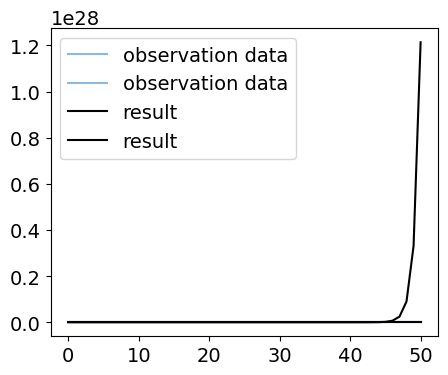

In [ ]:
n = 50

# Initialize the simulation object
sim = SimulationBase()

# Configure the case study
sim.config.case_study.name = "lotka_volterra_UDE_case_study"
sim.config.case_study.scenario = "UDETest"

key = jrandom.PRNGKey(5678)
data_key, model_key, optim_key = jrandom.split(key, 3)

# Add the model to the simulation
sim.model = Func({"alpha":jnp.array(1.3), "delta":jnp.array(1.8)},key=model_key)

# Define a solver
sim.solver = UDESolver

ts,ys = get_data(n, [1.3,0.9,0.8,1.8], 5, 1, 50, 51, 0.0, key=jr.PRNGKey(0))

# Create an xArray dataset containing the artificial data
datasets = jnp.linspace(0,n-1,n)

test_data1 = xr.DataArray(ys[:,:,0], coords={"batch_id": datasets, "time": ts}).to_dataset(name="prey")
test_data2 = xr.DataArray(ys[:,:,1], coords={"batch_id": datasets, "time": ts}).to_dataset(name="predator")
test_data = xr.merge([test_data1, test_data2])

# Add our dataset to the simulation
sim.observations = test_data

# Add the initial condition to the simulation
sim.model_parameters["y0"] = sim.observations.sel(time = 0).drop_vars("time")

sim.config.model_parameters.alpha = Param(value=1.3, free=False)
sim.config.model_parameters.delta = Param(value=1.8, free=True)
sim.config.model_parameters.delta.prior = "uniform(loc=1.0,scale=2.0)"

sim.model_parameters["parameters"] = sim.config.model_parameters.value_dict

# Create an xArray dataset containing the external input data
# xin = xr.DataArray(np.zeros(201), coords={"time": ts}).to_dataset(name="x_in")

# Add external inputs to the simulation
# sim.model_parameters["x_in"] = xin

# sim.config.jaxsolver.max_steps = 10000
sim.config.jaxsolver.throw_exception = False

# Put everything in place for running the simulation
sim.dispatch_constructor()

# Create an evaluator
evaluator = sim.dispatch()

Initialize inferer

In [13]:
sim.config.inference_optax.MLP_weight_dist = "normal()"
sim.config.inference_optax.MLP_bias_dist = "normal()"
sim.config.inference_optax.batch_size = 20
sim.config.inference_optax.data_split = 0.8
sim.config.inference_optax.multiple_runs_target = 10
sim.config.inference_optax.multiple_runs_limit = 20
sim.config.inference_optax.time_limit = 600

sim.config.inference_optax.length_strategy = [0.1,1]
sim.config.inference_optax.lr_strategy = 0.01
sim.config.inference_optax.steps_strategy = [1000, 1000]
sim.config.inference_optax.clip_strategy = 0.1
sim.config.inference_optax.indepth = "partial"

sim.set_inferer("optax")

# grad_loss_debug(model, ts, ys, 5, x_in, loss_func)
# self.simulation.evaluator._solver.standalone_solver(model, ts, ys[0,0], x_in)

Runs inferer (implementation using the `standalone_solver` workaround)

In [14]:
sim.inferer.run(optim_key)

4 of 10 runs completed:  40%|████      | 8000/20000 [14:51<19:49, 10.09it/s, 16 unsuccessful runs so far] C:\Users\Markus\pymob\pymob\inference\optax_backend.py:1037: UserWarning: Target number of successful runs was not reached before surpassing the allowed total number of runs. Only 4 optimized models were returned.
  warnings.warn(
4 of 10 runs completed:  40%|████      | 8000/20000 [14:55<22:23,  8.93it/s, 16 unsuccessful runs so far]



run number	successful?	loss

run 1		no		---
run 2		no		---
run 3		no		---
run 4		yes		1.8428447246551514
run 5		no		---
run 6		no		---
run 7		no		---
run 8		no		---
run 9		no		---
run 10		no		---
run 11		yes		1.2522666454315186
run 12		no		---
run 13		no		---
run 14		no		---
run 15		no		---
run 16		no		---
run 17		yes		1.6939454078674316
run 18		no		---
run 19		no		---
run 20		yes		1.9394396543502808


Save results

In [110]:
sim.inferer.store_results("failed_training/negative_values.nc", "failed_training/negative_values_f.nc")

Plot one of the five problematic time series

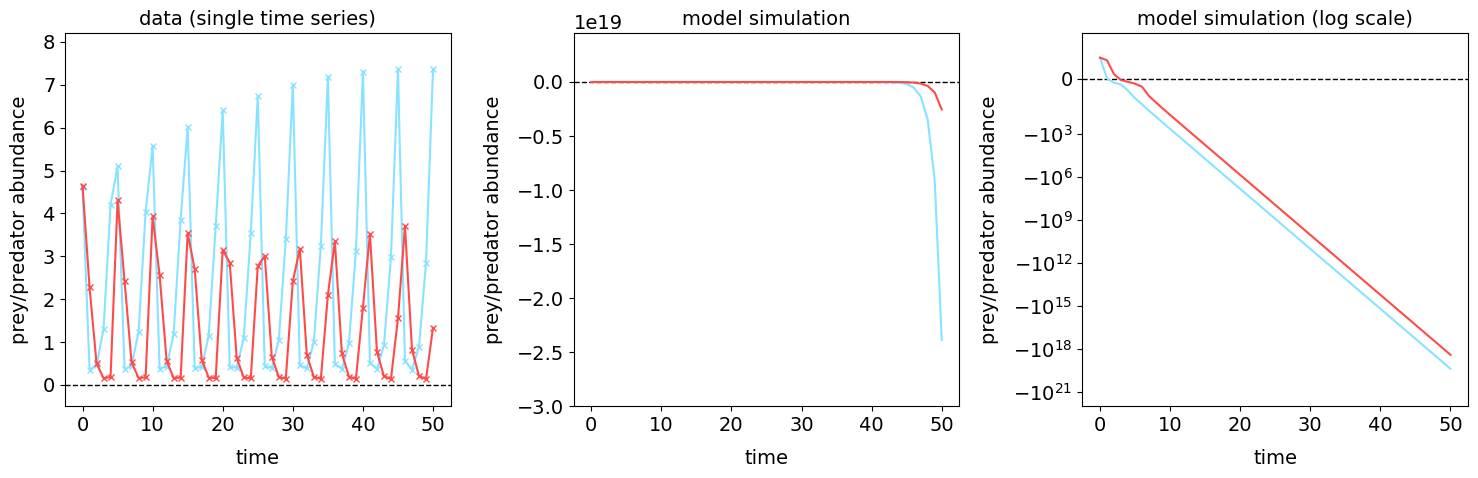

In [111]:
rcParams["font.size"] = 14
rcParams['axes.labelpad'] = 10

model_no = 1
data_no = 2

problem = evaluator._solver.standalone_solver(sim.inferer.failed_models[model_no], ts, ys[data_no,0], ())

fig, (ax_data,ax,ax2) = plt.subplots(ncols=3, figsize=(15,5))

ax_data.plot(ts, ys[data_no,:,0], "x-", markersize=5, c="#87E3FF", label="prey data")
ax_data.plot(ts, ys[data_no,:,1], "x-", markersize=5, c="#FF4A4A", label="predator data")
ax_data.axhline(0, linestyle="--", linewidth=1, color="black")
ax_data.set_xlabel("time", fontsize=14)
ax_data.set_ylabel("prey/predator abundance", fontsize=14)
ax_data.set_title("data (single time series)", fontsize=14)
ax_data.set(ylim=(-0.5,8.2))

ax.axhline(0, linestyle="--", linewidth=1, color="black")
ax.plot(ts, problem[0], c="#87E3FF", label="prey")
ax.plot(ts, problem[1], c="#FF4A4A", label="predator")
ax.yaxis.minorticks_off()
ax.set(ylim=(-3e19, 0.45e19))
ax.set_xlabel("time", fontsize=14)
ax.set_ylabel("prey/predator abundance", fontsize=14)
ax.set_title("model simulation", fontsize=14)

ax2.set_yscale("symlog")
ax2.axhline(0, linestyle="--", linewidth=1, color="black")
ax2.plot(ts, problem[0], c="#87E3FF", label="prey")
ax2.plot(ts, problem[1], c="#FF4A4A", label="predator")
ax2.set(ylim=(-1e22, 2.3e2), yticks=[0,-1e3,-1e6,-1e9,-1e12,-1e15,-1e18,-1e21])
ax2.set_xlabel("time", fontsize=14)
ax2.set_ylabel("prey/predator abundance", fontsize=14)
ax2.set_title("model simulation (log scale)", fontsize=14)
ax2.yaxis.minorticks_off()

fig.tight_layout()
fig.savefig("failed_training/negative_values.png")

#### Variant 2: Load data

Model formulation

In [3]:
class Func(UDEBase):

    mlp_depth: int = 3
    mlp_width: int = 3
    mlp_in_size: int = 2
    mlp_out_size: int = 2
    mlp_activation: Callable = staticmethod(jnn.softplus)
    mlp_final_activation: Callable = staticmethod(jnn.identity)

    alpha: jax.Array
    delta: jax.Array
    
    @staticmethod
    def model(t, y, mlp, alpha, delta, ):
        prey, predator = y
        
        dprey_dt_ode = alpha * prey 
        dpredator_dt_ode = - delta * predator
        dprey_dt_nn, dpredator_dt_nn = mlp(y)

        dprey_dt = dprey_dt_ode + dprey_dt_nn
        dpredator_dt = dpredator_dt_ode + dpredator_dt_nn

        return dprey_dt, dpredator_dt
    
    @staticmethod
    def loss(y_obs, y_pred):
        return (y_obs - y_pred)**2

Create models from data

In [4]:
idata = az.from_netcdf("failed_training/negative_values_f.nc")

model_key = jr.PRNGKey(0)
models = [Func({"alpha":jnp.array(1.3), "delta":idata.posterior.sel(draw=i).delta.values[0]},weights=idata.posterior.sel(draw=i).weights.values.tolist()[0],bias=idata.posterior.sel(draw=i).bias.values.tolist()[0],key=model_key) for i in np.arange(0, 10)]

Create SimulationBase, observation data, and Evaluator

In [ ]:
n = 50

# Initialize the simulation object
sim = SimulationBase()

# Configure the case study
sim.config.case_study.name = "lotka_volterra_UDE_case_study"
sim.config.case_study.scenario = "UDETest"

key = jrandom.PRNGKey(5678)
data_key, model_key, optim_key = jrandom.split(key, 3)

# Add the model to the simulation
sim.model = Func({"alpha":jnp.array(1.3), "delta":jnp.array(1.8)},key=model_key)

# Define a solver
sim.solver = UDESolver

ts,ys = get_data(n, [1.3,0.9,0.8,1.8], 5, 1, 50, 51, 0.0, key=jr.PRNGKey(0))

# Create an xArray dataset containing the artificial data
datasets = jnp.linspace(0,n-1,n)

test_data1 = xr.DataArray(ys[:,:,0], coords={"batch_id": datasets, "time": ts}).to_dataset(name="prey")
test_data2 = xr.DataArray(ys[:,:,1], coords={"batch_id": datasets, "time": ts}).to_dataset(name="predator")
test_data = xr.merge([test_data1, test_data2])

# Add our dataset to the simulation
sim.observations = test_data

# Add the initial condition to the simulation
sim.model_parameters["y0"] = sim.observations.sel(time = 0).drop_vars("time")

sim.config.model_parameters.alpha = Param(value=1.3, free=False)
sim.config.model_parameters.delta = Param(value=1.8, free=True)
sim.config.model_parameters.delta.prior = "uniform(loc=1.0,scale=2.0)"

sim.model_parameters["parameters"] = sim.config.model_parameters.value_dict

# Create an xArray dataset containing the external input data
# xin = xr.DataArray(np.zeros(201), coords={"time": ts}).to_dataset(name="x_in")

# Add external inputs to the simulation
# sim.model_parameters["x_in"] = xin

# sim.config.jaxsolver.max_steps = 10000
sim.config.jaxsolver.throw_exception = False

# Put everything in place for running the simulation
sim.dispatch_constructor()

# Create an evaluator
evaluator = sim.dispatch()

C:\Users\Markus\pymob\pymob\simulation.py:309: UserWarning: `sim.config.data_structure.prey = Datavariable(dimensions=['batch_id', 'time'] min=0.3567415475845337 max=7.36574125289917 observed=True dimensions_evaluator=None)` has been assumed from `sim.observations`. If the order of the dimensions should be different, specify `sim.config.data_structure.prey = DataVariable(dimensions=[...], ...)` manually.
  warnings.warn(
C:\Users\Markus\pymob\pymob\simulation.py:309: UserWarning: `sim.config.data_structure.predator = Datavariable(dimensions=['batch_id', 'time'] min=0.13458672165870667 max=5.283197402954102 observed=True dimensions_evaluator=None)` has been assumed from `sim.observations`. If the order of the dimensions should be different, specify `sim.config.data_structure.predator = DataVariable(dimensions=[...], ...)` manually.
  warnings.warn(
C:\Users\Markus\pymob\pymob\simulation.py:579: UserWarning: The number of ODE states was not specified in the config file [simulation] > 'n_

MinMaxScaler(variable=prey, min=0.3567415475845337, max=7.36574125289917)
MinMaxScaler(variable=predator, min=0.13458672165870667, max=5.283197402954102)


Plot one of the five problematic time series

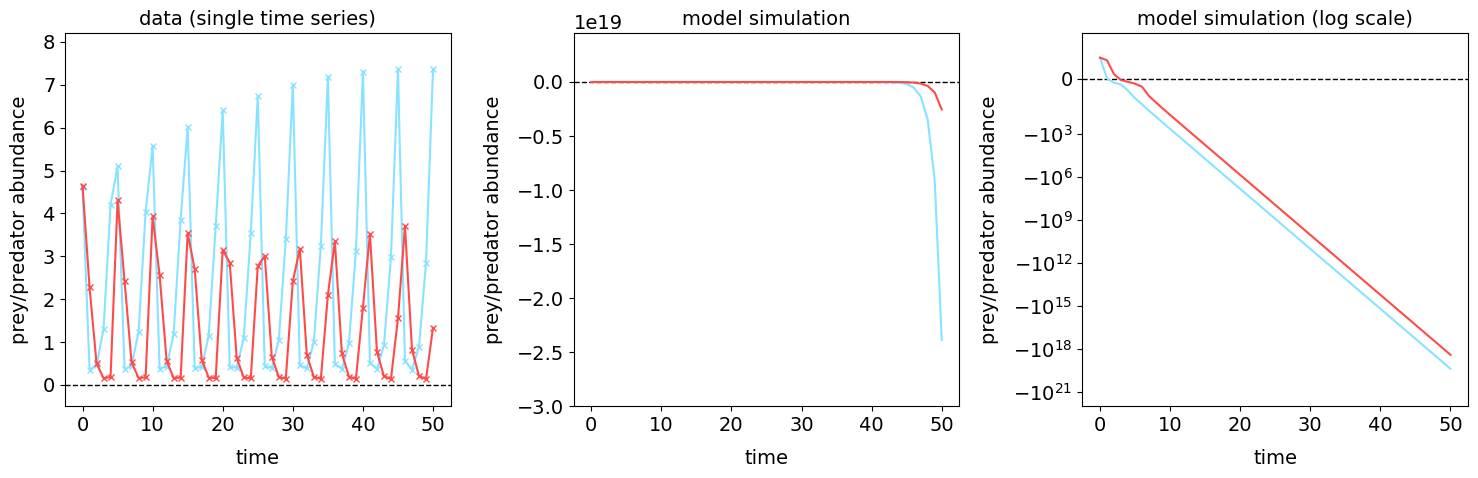

In [ ]:
rcParams["font.size"] = 14
rcParams['axes.labelpad'] = 10

model_no = 1
data_no = 2

problem = evaluator._solver.standalone_solver(models[model_no], ts, ys[data_no,0], ())

fig, (ax_data,ax,ax2) = plt.subplots(ncols=3, figsize=(15,5))

ax_data.plot(ts, ys[data_no,:,0], "x-", markersize=5, c="#87E3FF", label="prey data")
ax_data.plot(ts, ys[data_no,:,1], "x-", markersize=5, c="#FF4A4A", label="predator data")
ax_data.axhline(0, linestyle="--", linewidth=1, color="black")
ax_data.set_xlabel("time", fontsize=14)
ax_data.set_ylabel("prey/predator abundance", fontsize=14)
ax_data.set_title("data (single time series)", fontsize=14)
ax_data.set(ylim=(-0.5,8.2))

ax.axhline(0, linestyle="--", linewidth=1, color="black")
ax.plot(ts, problem[0], c="#87E3FF", label="prey")
ax.plot(ts, problem[1], c="#FF4A4A", label="predator")
ax.yaxis.minorticks_off()
ax.set(ylim=(-3e19, 0.45e19))
ax.set_xlabel("time", fontsize=14)
ax.set_ylabel("prey/predator abundance", fontsize=14)
ax.set_title("model simulation", fontsize=14)

ax2.set_yscale("symlog")
ax2.axhline(0, linestyle="--", linewidth=1, color="black")
ax2.plot(ts, problem[0], c="#87E3FF", label="prey")
ax2.plot(ts, problem[1], c="#FF4A4A", label="predator")
ax2.set(ylim=(-1e22, 2.3e2), yticks=[0,-1e3,-1e6,-1e9,-1e12,-1e15,-1e18,-1e21])
ax2.set_xlabel("time", fontsize=14)
ax2.set_ylabel("prey/predator abundance", fontsize=14)
ax2.set_title("model simulation (log scale)", fontsize=14)
ax2.yaxis.minorticks_off()

fig.tight_layout()
fig.savefig("failed_training/negative_values.png")

### Model for Figure 10 (close to zero)

#### Variant 1: Run inference process

In [3]:
class Func(UDEBase):

    mlp_depth: int = 3
    mlp_width: int = 3
    mlp_in_size: int = 2
    mlp_out_size: int = 2
    mlp_activation: Callable = staticmethod(jnn.softplus)
    mlp_final_activation: Callable = staticmethod(jnn.identity)

    alpha: jax.Array
    delta: jax.Array
    
    @staticmethod
    def model(t, y, mlp, alpha, delta, ):
        prey, predator = y
        
        dprey_dt_ode = alpha * prey 
        dpredator_dt_ode = - delta * predator
        dprey_dt_nn, dpredator_dt_nn = mlp(y) * jnp.array([jnp.tanh(prey).astype(float), jnp.tanh(predator).astype(float)])

        dprey_dt = dprey_dt_ode + dprey_dt_nn
        dpredator_dt = dpredator_dt_ode + dpredator_dt_nn

        return dprey_dt, dpredator_dt
    
    @staticmethod
    def loss(y_obs, y_pred):
        return (y_obs - y_pred)**2

Create a simulation with n=50 data batches

C:\Users\Markus\pymob\pymob\simulation.py:309: UserWarning: `sim.config.data_structure.prey = Datavariable(dimensions=['batch_id', 'time'] min=0.3567415475845337 max=7.36574125289917 observed=True dimensions_evaluator=None)` has been assumed from `sim.observations`. If the order of the dimensions should be different, specify `sim.config.data_structure.prey = DataVariable(dimensions=[...], ...)` manually.
  warnings.warn(
C:\Users\Markus\pymob\pymob\simulation.py:309: UserWarning: `sim.config.data_structure.predator = Datavariable(dimensions=['batch_id', 'time'] min=0.13458672165870667 max=5.283197402954102 observed=True dimensions_evaluator=None)` has been assumed from `sim.observations`. If the order of the dimensions should be different, specify `sim.config.data_structure.predator = DataVariable(dimensions=[...], ...)` manually.
  warnings.warn(
C:\Users\Markus\pymob\pymob\simulation.py:579: UserWarning: The number of ODE states was not specified in the config file [simulation] > 'n_

MinMaxScaler(variable=prey, min=0.3567415475845337, max=7.36574125289917)
MinMaxScaler(variable=predator, min=0.13458672165870667, max=5.283197402954102)


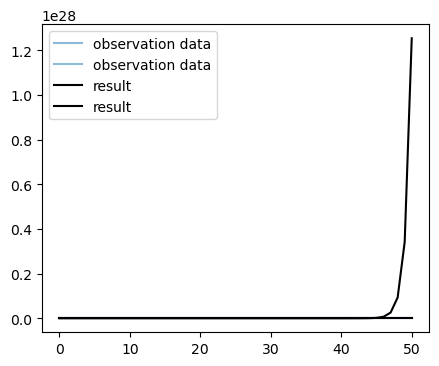

In [ ]:
n = 50

# Initialize the simulation object
sim = SimulationBase()

# Configure the case study
sim.config.case_study.name = "lotka_volterra_UDE_case_study"
sim.config.case_study.scenario = "UDETest"

key = jrandom.PRNGKey(5678)
data_key, model_key, optim_key = jrandom.split(key, 3)

# Add the model to the simulation
sim.model = Func({"alpha":jnp.array(1.3), "delta":jnp.array(1.8)},key=model_key)

# Define a solver
sim.solver = UDESolver

ts,ys = get_data(n, [1.3,0.9,0.8,1.8], 5, 1, 50, 51, 0.0, key=jr.PRNGKey(0))

# Create an xArray dataset containing the artificial data
datasets = jnp.linspace(0,n-1,n)

test_data1 = xr.DataArray(ys[:,:,0], coords={"batch_id": datasets, "time": ts}).to_dataset(name="prey")
test_data2 = xr.DataArray(ys[:,:,1], coords={"batch_id": datasets, "time": ts}).to_dataset(name="predator")
test_data = xr.merge([test_data1, test_data2])

# Add our dataset to the simulation
sim.observations = test_data

# Add the initial condition to the simulation
sim.model_parameters["y0"] = sim.observations.sel(time = 0).drop_vars("time")

sim.config.model_parameters.alpha = Param(value=1.3, free=False)
sim.config.model_parameters.delta = Param(value=1.8, free=True)
sim.config.model_parameters.delta.prior = "uniform(loc=1.0,scale=2.0)"

sim.model_parameters["parameters"] = sim.config.model_parameters.value_dict

# Create an xArray dataset containing the external input data
# xin = xr.DataArray(np.zeros(201), coords={"time": ts}).to_dataset(name="x_in")

# Add external inputs to the simulation
# sim.model_parameters["x_in"] = xin

# sim.config.jaxsolver.max_steps = 10000
sim.config.jaxsolver.throw_exception = False

# Put everything in place for running the simulation
sim.dispatch_constructor()

# Create an evaluator
evaluator = sim.dispatch()

Initialize inferer

In [5]:
sim.config.inference_optax.MLP_weight_dist = "normal()"
sim.config.inference_optax.MLP_bias_dist = "normal()"
sim.config.inference_optax.batch_size = 20
sim.config.inference_optax.data_split = 0.8
sim.config.inference_optax.multiple_runs_target = 10
sim.config.inference_optax.multiple_runs_limit = 20
sim.config.inference_optax.time_limit = 600

sim.config.inference_optax.length_strategy = [0.1,1]
sim.config.inference_optax.lr_strategy = 0.01
sim.config.inference_optax.steps_strategy = [1000, 1000]
sim.config.inference_optax.clip_strategy = 0.1
sim.config.inference_optax.indepth = "full"

sim.set_inferer("optax")

# grad_loss_debug(model, ts, ys, 5, x_in, loss_func)
# self.simulation.evaluator._solver.standalone_solver(model, ts, ys[0,0], x_in)

Runs inferer (implementation using the `standalone_solver` workaround)

In [18]:
sim.inferer.run(jr.PRNGKey(42))

10 of 10 runs completed: 100%|██████████| 20000/20000 [31:36<00:00, 10.55it/s, 2 unsuccessful runs so far]  



run number	successful?	loss

run 1		yes		1.3389878273010254
run 2		yes		1.7505604028701782
run 3		yes		1.8473336696624756
run 4		yes		2.004380702972412
run 5		yes		1.7935740947723389
run 6		yes		1.220081090927124
run 7		yes		1.4153591394424438
run 8		no		---
run 9		no		---
run 10		yes		1.4344494342803955
run 11		yes		1.1021947860717773
run 12		yes		2.260481119155884


Save results

In [31]:
sim.inferer.store_results("failed_training/close_to_zero.nc", "failed_training/close_to_zero_f.nc")

Plot one of the four problematic initial conditions

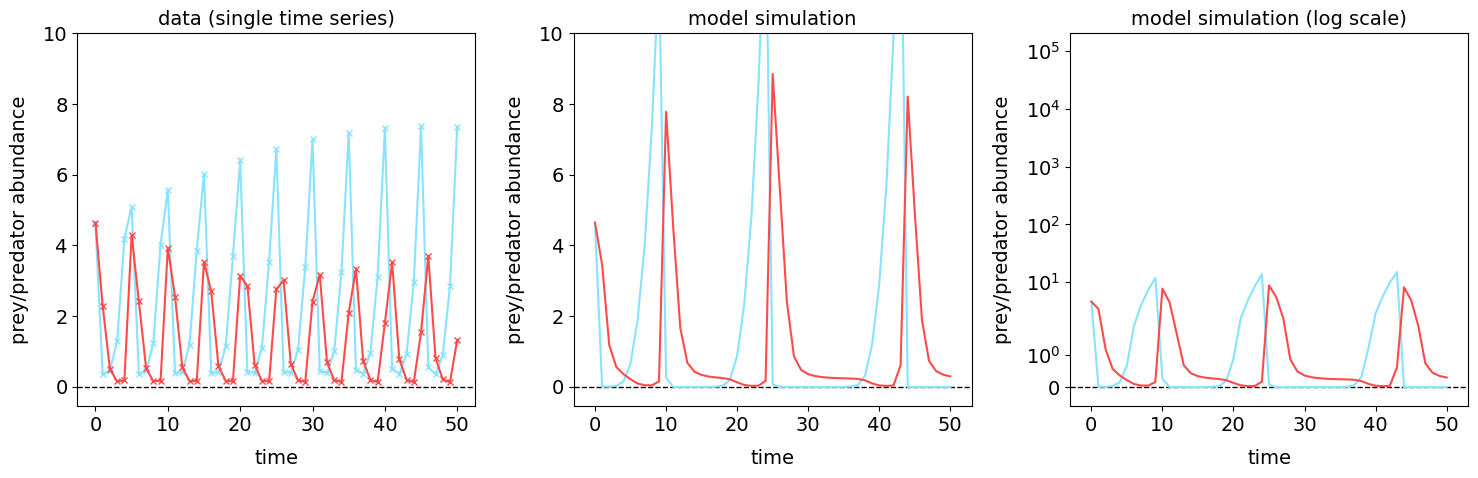

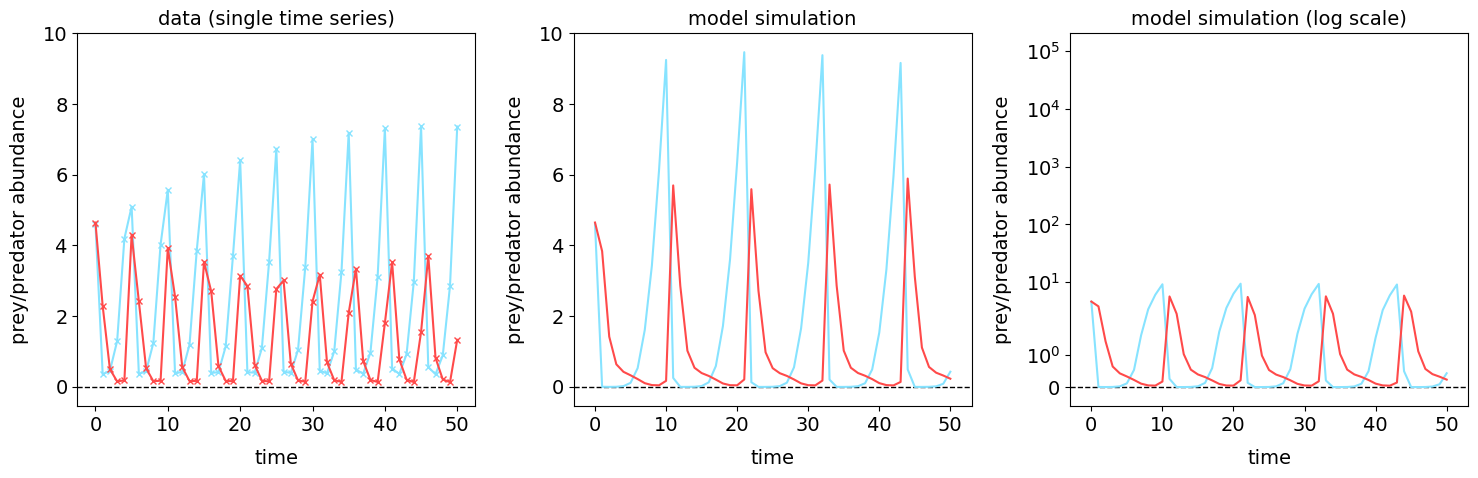

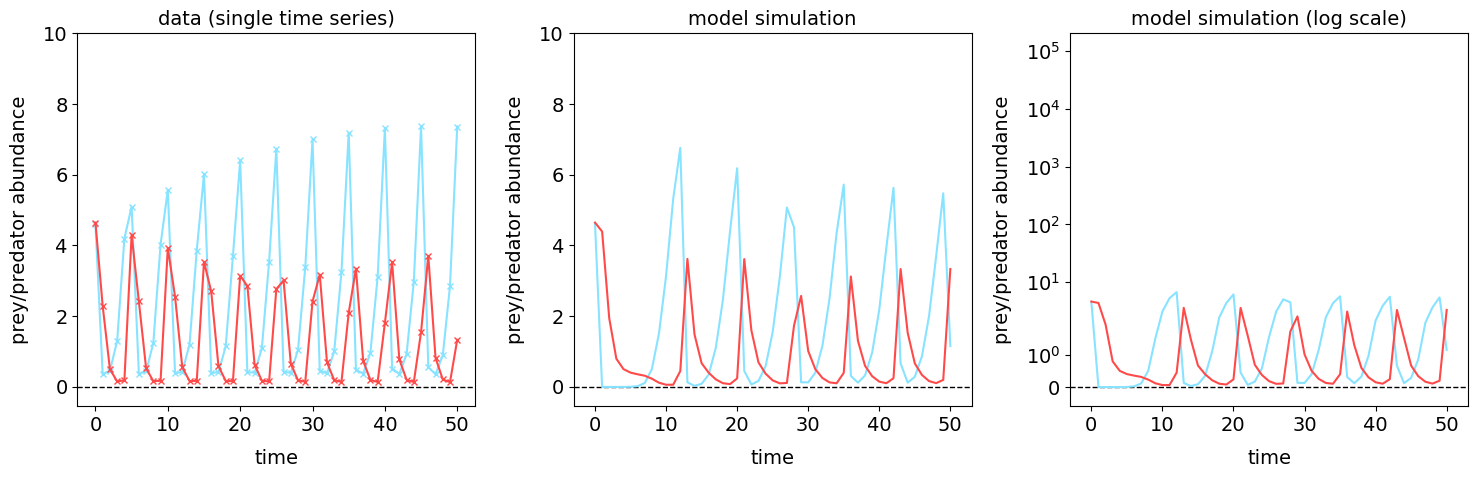

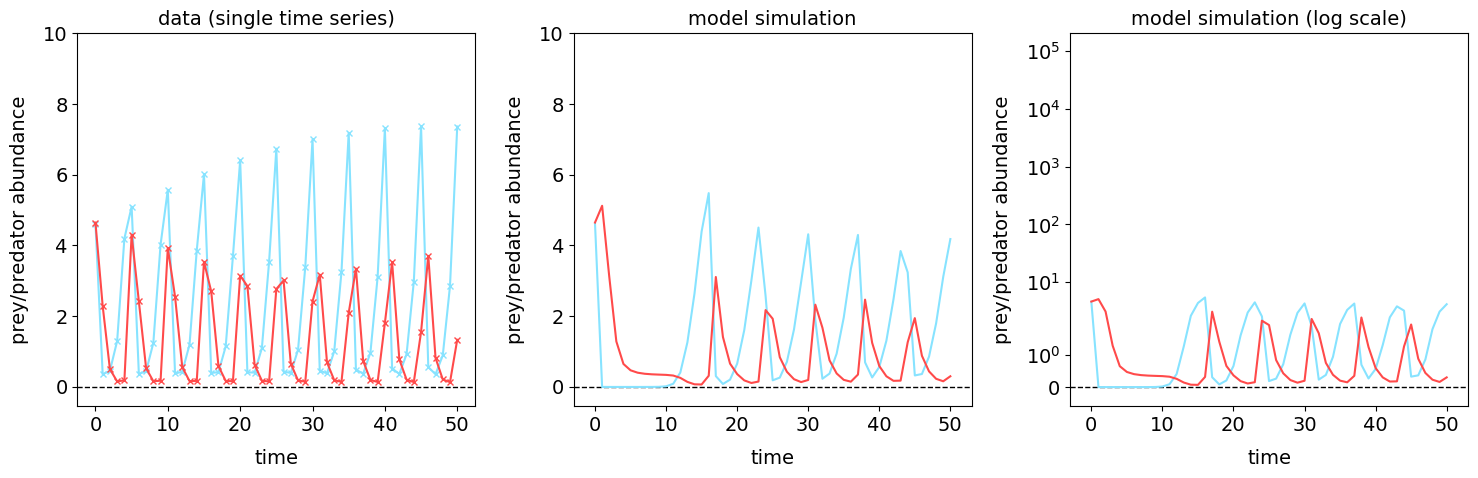

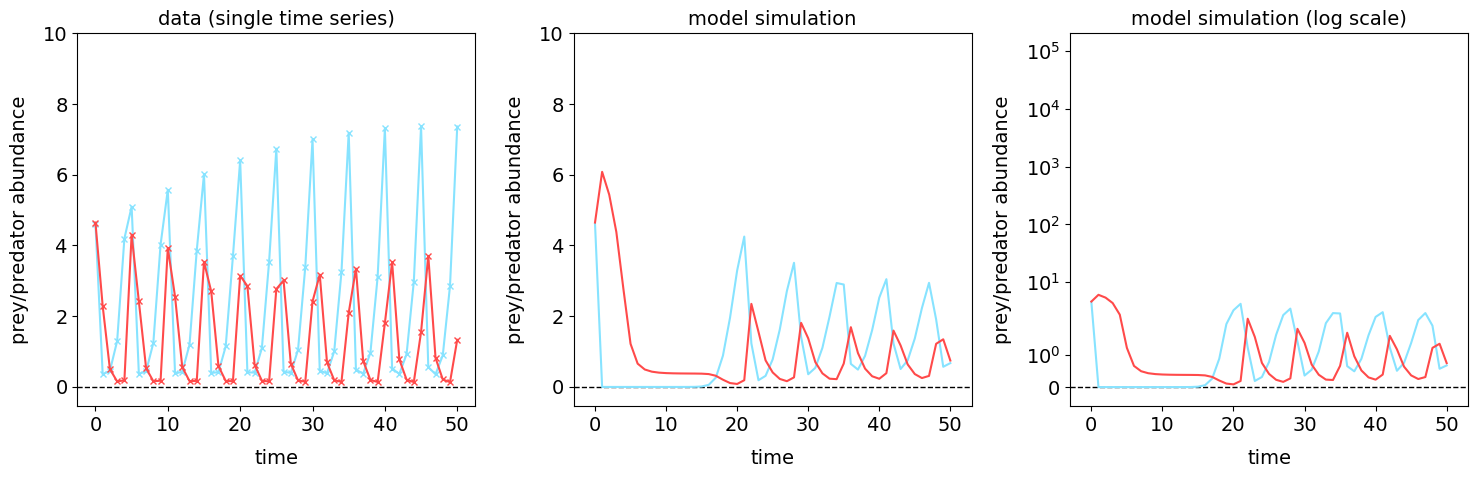

In [62]:
rcParams["font.size"] = 14
rcParams['axes.labelpad'] = 10

model_no = 0
data_no = 2

for step in [-7,-6,-5,-4,-3]:

    problem = evaluator._solver.standalone_solver(sim.inferer.failed_models[model_no][step], ts, ys[data_no,0], ())

    fig, (ax_data,ax,ax2) = plt.subplots(ncols=3, figsize=(15,5))

    ax_data.plot(ts, ys[data_no,:,0], "x-", markersize=5, c="#87E3FF", label="prey data")
    ax_data.plot(ts, ys[data_no,:,1], "x-", markersize=5, c="#FF4A4A", label="predator data")
    ax_data.axhline(0, linestyle="--", linewidth=1, color="black")
    ax_data.set_xlabel("time", fontsize=14)
    ax_data.set_ylabel("prey/predator abundance", fontsize=14)
    ax_data.set_title("data (single time series)", fontsize=14)
    ax_data.set(ylim=(-0.55,10))

    ax.axhline(0, xmin=0, xmax=1, linestyle="--", linewidth=1, color="black")
    ax.plot(ts, problem[0], c="#87E3FF", label="prey")
    ax.plot(ts, problem[1], c="#FF4A4A", label="predator")
    ax.yaxis.minorticks_off()
    ax.set(xlim=(-3,53), ylim=(-0.55,10))
    ax.set_xlabel("time", fontsize=14)
    ax.set_ylabel("prey/predator abundance", fontsize=14)
    ax.set_title("model simulation", fontsize=14)

    ax2.set_yscale("symlog")
    ax2.axhline(0, xmax=1, linestyle="--", linewidth=1, color="black")
    ax2.plot(ts, problem[0], c="#87E3FF", label="prey")
    ax2.plot(ts, problem[1], c="#FF4A4A", label="predator")
    ax2.set(xlim=(-3,53), ylim=(-0.6,200000))
    ax2.set_xlabel("time", fontsize=14)
    ax2.set_ylabel("prey/predator abundance", fontsize=14)
    ax2.set_title("model simulation (log scale)", fontsize=14)
    ax2.yaxis.minorticks_off()

    fig.tight_layout()
    fig.savefig(f"failed_training/close_to_zero_{str(-2-step)}_beforefailure.png")

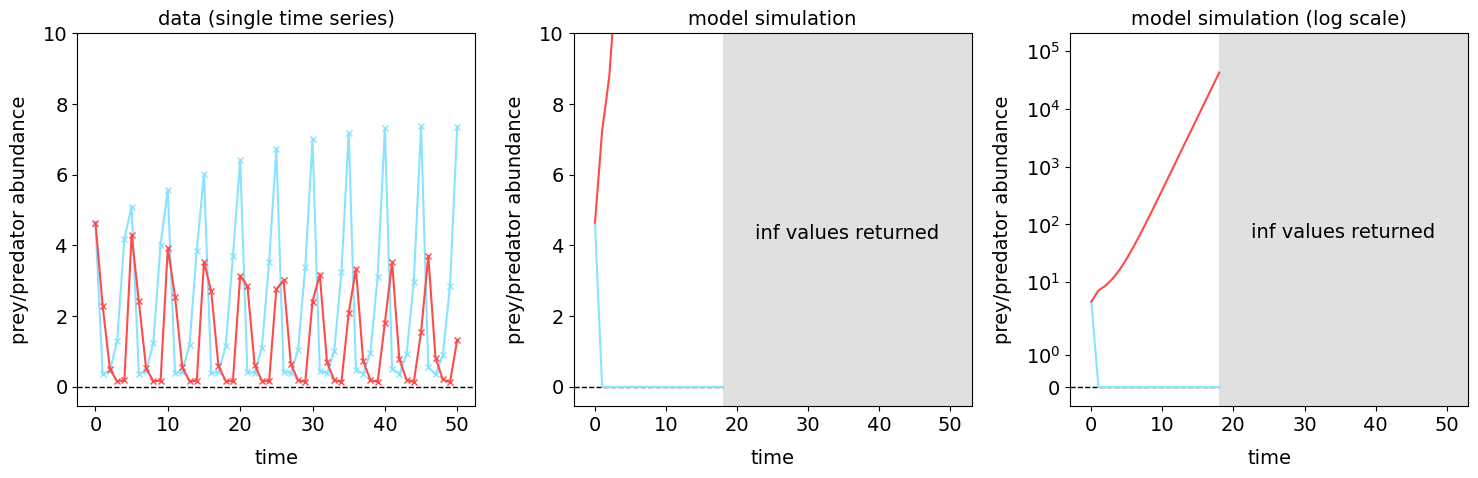

In [60]:
from matplotlib.patches import Rectangle

rcParams["font.size"] = 14
rcParams['axes.labelpad'] = 10

model_no = 0
data_no = 2

problem = evaluator._solver.standalone_solver(sim.inferer.failed_models[model_no][-2], ts, ys[data_no,0], ())

fig, (ax_data,ax,ax2) = plt.subplots(ncols=3, figsize=(15,5))

ax_data.plot(ts, ys[data_no,:,0], "x-", markersize=5, c="#87E3FF", label="prey data")
ax_data.plot(ts, ys[data_no,:,1], "x-", markersize=5, c="#FF4A4A", label="predator data")
ax_data.axhline(0, linestyle="--", linewidth=1, color="black")
ax_data.set_xlabel("time", fontsize=14)
ax_data.set_ylabel("prey/predator abundance", fontsize=14)
ax_data.set_title("data (single time series)", fontsize=14)
ax_data.set(ylim=(-0.55,10))

ax.axhline(0, xmin=0, xmax=21/56, linestyle="--", linewidth=1, color="black")
ax.plot(ts, problem[0], c="#87E3FF", label="prey")
ax.plot(ts, problem[1], c="#FF4A4A", label="predator")
ax.add_patch(Rectangle((18,-0.7),35,11,facecolor="#E0E0E0"))
ax.yaxis.minorticks_off()
ax.set(xlim=(-3,53), ylim=(-0.55,10))
ax.set_xlabel("time", fontsize=14)
ax.set_ylabel("prey/predator abundance", fontsize=14)
ax.set_title("model simulation", fontsize=14)
ax.text(22.5,4.17,"inf values returned",rotation=0,size=14)

ax2.set_yscale("symlog")
ax2.axhline(0, xmax=21/56, linestyle="--", linewidth=1, color="black")
ax2.plot(ts, problem[0], c="#87E3FF", label="prey")
ax2.plot(ts, problem[1], c="#FF4A4A", label="predator")
ax2.add_patch(Rectangle((18,-0.6),35,200001,facecolor="#E0E0E0"))
ax2.set(xlim=(-3,53), ylim=(-0.6,200000))
ax2.set_xlabel("time", fontsize=14)
ax2.set_ylabel("prey/predator abundance", fontsize=14)
ax2.set_title("model simulation (log scale)", fontsize=14)
ax2.yaxis.minorticks_off()
ax2.text(22.5,58,"inf values returned",rotation=0,size=14)

# fig.suptitle("Lotka-Volterra UDE model successful training (with noise)")
fig.tight_layout()
fig.savefig("failed_training/close_to_zero_afterfailure.png")

#### Variant 2: Load data

Model formulation

In [29]:
class Func(UDEBase):

    mlp_depth: int = 3
    mlp_width: int = 3
    mlp_in_size: int = 2
    mlp_out_size: int = 2
    mlp_activation: Callable = staticmethod(jnn.softplus)
    mlp_final_activation: Callable = staticmethod(jnn.identity)

    alpha: jax.Array
    delta: jax.Array
    
    @staticmethod
    def model(t, y, mlp, alpha, delta, ):
        prey, predator = y
        
        dprey_dt_ode = alpha * prey 
        dpredator_dt_ode = - delta * predator
        dprey_dt_nn, dpredator_dt_nn = mlp(y) * jnp.array([jnp.tanh(prey).astype(float), jnp.tanh(predator).astype(float)])

        dprey_dt = dprey_dt_ode + dprey_dt_nn
        dpredator_dt = dpredator_dt_ode + dpredator_dt_nn

        return dprey_dt, dpredator_dt
    
    @staticmethod
    def loss(y_obs, y_pred):
        return (y_obs - y_pred)**2

Create models from data

In [72]:
idata = az.from_netcdf("failed_training/close_to_zero_f.nc")

model_key = jr.PRNGKey(0)
models = [[Func({"alpha":jnp.array(1.3), "delta":idata.posterior.sel(draw=i, step=j).delta.values[0]},weights=idata.posterior.sel(draw=i, step=j).weights.values.tolist()[0],bias=idata.posterior.sel(draw=i, step=j).bias.values.tolist()[0],key=model_key) for j in np.arange(0,2001)] for i in [0,1]]

Create SimulationBase, observation data, and Evaluator

In [ ]:
n = 50

# Initialize the simulation object
sim = SimulationBase()

# Configure the case study
sim.config.case_study.name = "lotka_volterra_UDE_case_study"
sim.config.case_study.scenario = "UDETest"

key = jrandom.PRNGKey(5678)
data_key, model_key, optim_key = jrandom.split(key, 3)

# Add the model to the simulation
sim.model = Func({"alpha":jnp.array(1.3), "delta":jnp.array(1.8)},key=model_key)

# Define a solver
sim.solver = UDESolver

ts,ys = get_data(n, [1.3,0.9,0.8,1.8], 5, 1, 50, 51, 0.0, key=jr.PRNGKey(0))

# Create an xArray dataset containing the artificial data
datasets = jnp.linspace(0,n-1,n)

test_data1 = xr.DataArray(ys[:,:,0], coords={"batch_id": datasets, "time": ts}).to_dataset(name="prey")
test_data2 = xr.DataArray(ys[:,:,1], coords={"batch_id": datasets, "time": ts}).to_dataset(name="predator")
test_data = xr.merge([test_data1, test_data2])

# Add our dataset to the simulation
sim.observations = test_data

# Add the initial condition to the simulation
sim.model_parameters["y0"] = sim.observations.sel(time = 0).drop_vars("time")

sim.config.model_parameters.alpha = Param(value=1.3, free=False)
sim.config.model_parameters.delta = Param(value=1.8, free=True)
sim.config.model_parameters.delta.prior = "uniform(loc=1.0,scale=2.0)"

sim.model_parameters["parameters"] = sim.config.model_parameters.value_dict

# Create an xArray dataset containing the external input data
# xin = xr.DataArray(np.zeros(201), coords={"time": ts}).to_dataset(name="x_in")

# Add external inputs to the simulation
# sim.model_parameters["x_in"] = xin

# sim.config.jaxsolver.max_steps = 10000
sim.config.jaxsolver.throw_exception = False

# Put everything in place for running the simulation
sim.dispatch_constructor()

# Create an evaluator
evaluator = sim.dispatch()

MinMaxScaler(variable=prey, min=0.3567415475845337, max=7.36574125289917)
MinMaxScaler(variable=predator, min=0.13458672165870667, max=5.283197402954102)


C:\Users\Markus\pymob\pymob\simulation.py:309: UserWarning: `sim.config.data_structure.prey = Datavariable(dimensions=['batch_id', 'time'] min=0.3567415475845337 max=7.36574125289917 observed=True dimensions_evaluator=None)` has been assumed from `sim.observations`. If the order of the dimensions should be different, specify `sim.config.data_structure.prey = DataVariable(dimensions=[...], ...)` manually.
  warnings.warn(
C:\Users\Markus\pymob\pymob\simulation.py:309: UserWarning: `sim.config.data_structure.predator = Datavariable(dimensions=['batch_id', 'time'] min=0.13458672165870667 max=5.283197402954102 observed=True dimensions_evaluator=None)` has been assumed from `sim.observations`. If the order of the dimensions should be different, specify `sim.config.data_structure.predator = DataVariable(dimensions=[...], ...)` manually.
  warnings.warn(
C:\Users\Markus\pymob\pymob\simulation.py:579: UserWarning: The number of ODE states was not specified in the config file [simulation] > 'n_

Plot one of the four problematic initial conditions

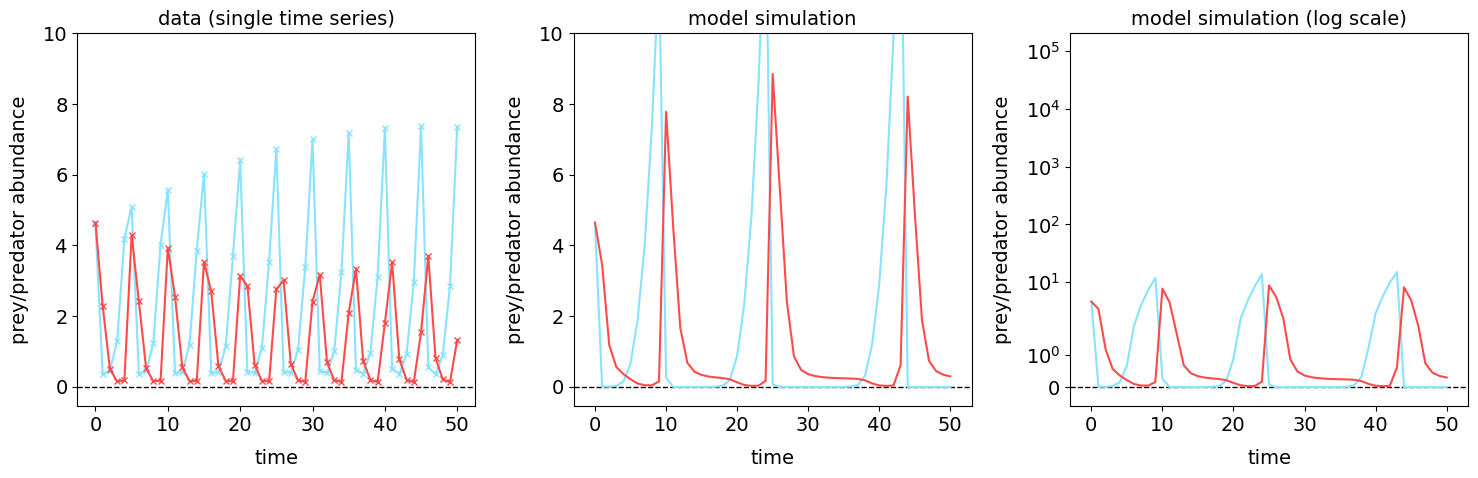

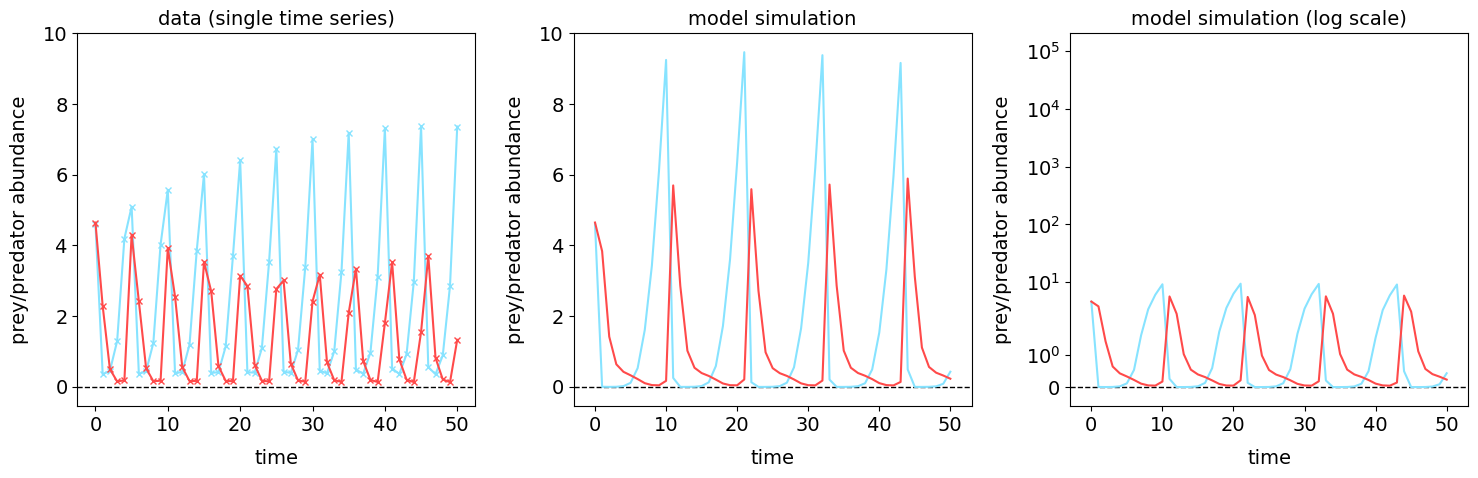

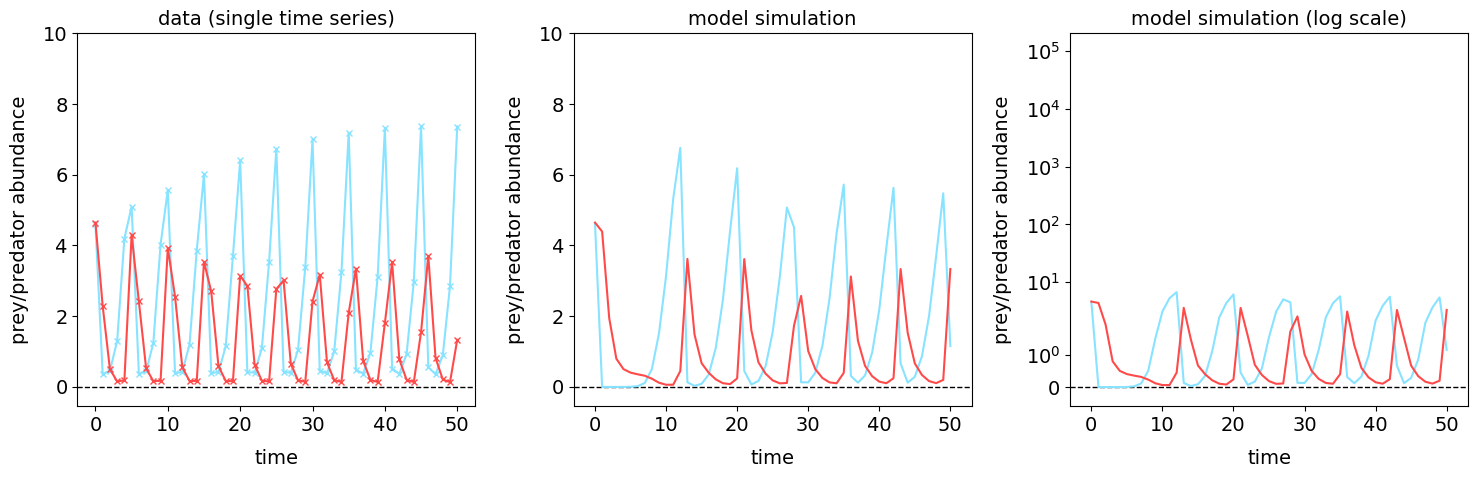

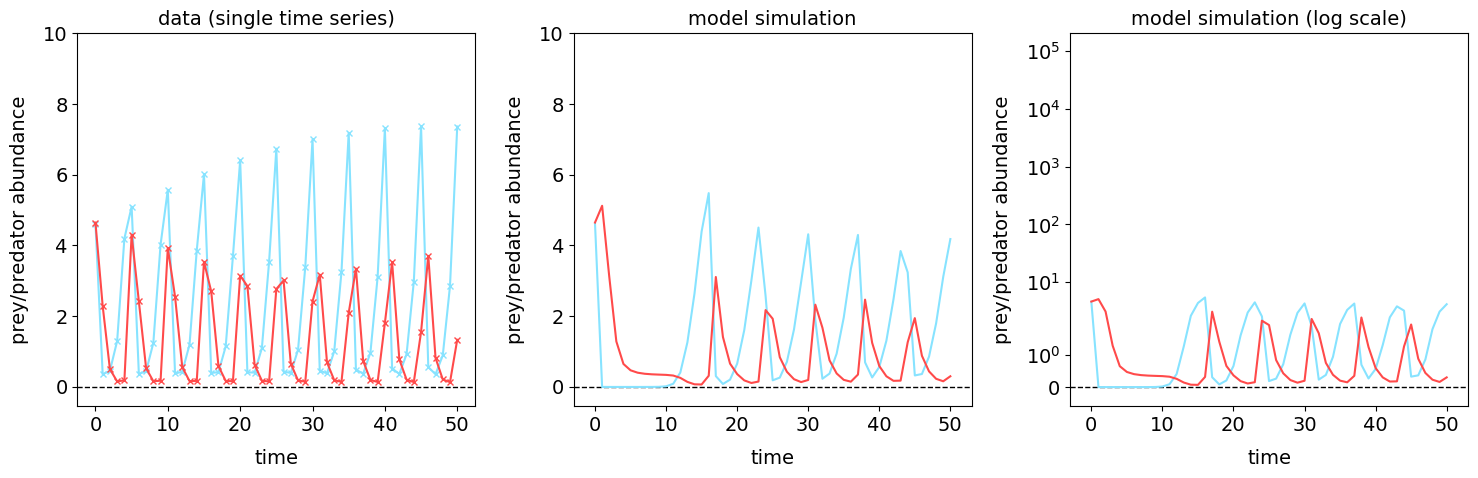

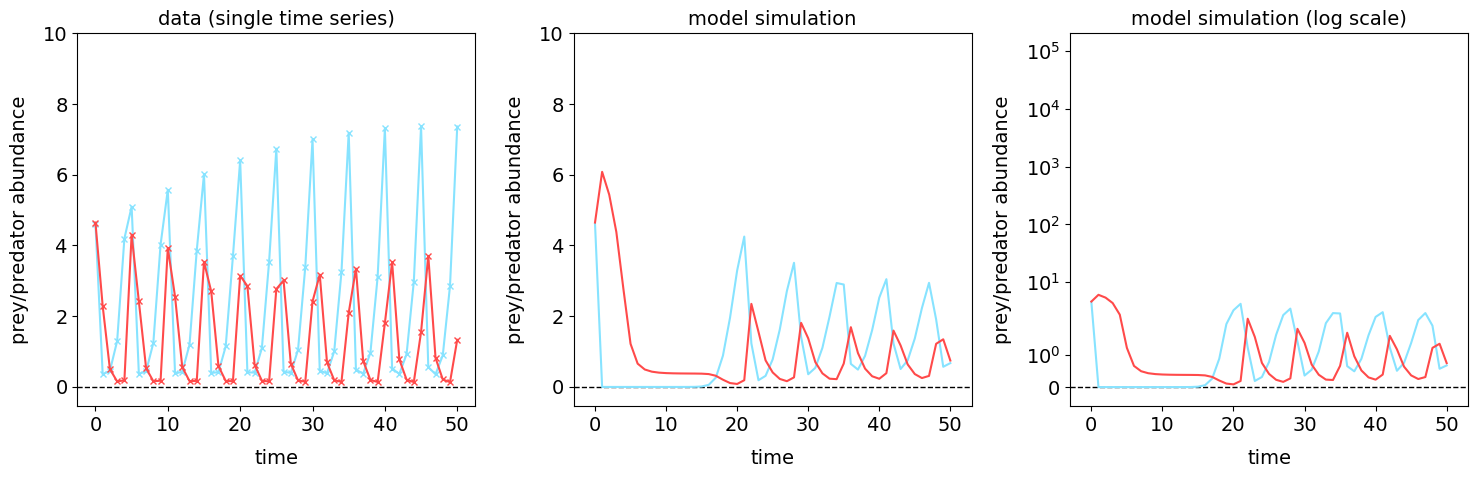

In [ ]:
rcParams["font.size"] = 14
rcParams['axes.labelpad'] = 10

model_no = 0
data_no = 2

deltas = idata.posterior.delta.sel(draw=model_no).values
last_step = np.sum(np.isnan(deltas[-1]))

for step in [-7,-6,-5,-4,-3]:

    problem = evaluator._solver.standalone_solver(models[model_no][step-last_step], ts, ys[data_no,0], ())

    fig, (ax_data,ax,ax2) = plt.subplots(ncols=3, figsize=(15,5))

    ax_data.plot(ts, ys[data_no,:,0], "x-", markersize=5, c="#87E3FF", label="prey data")
    ax_data.plot(ts, ys[data_no,:,1], "x-", markersize=5, c="#FF4A4A", label="predator data")
    ax_data.axhline(0, linestyle="--", linewidth=1, color="black")
    ax_data.set_xlabel("time", fontsize=14)
    ax_data.set_ylabel("prey/predator abundance", fontsize=14)
    ax_data.set_title("data (single time series)", fontsize=14)
    ax_data.set(ylim=(-0.55,10))

    ax.axhline(0, xmin=0, xmax=1, linestyle="--", linewidth=1, color="black")
    ax.plot(ts, problem[0], c="#87E3FF", label="prey")
    ax.plot(ts, problem[1], c="#FF4A4A", label="predator")
    ax.yaxis.minorticks_off()
    ax.set(xlim=(-3,53), ylim=(-0.55,10))
    ax.set_xlabel("time", fontsize=14)
    ax.set_ylabel("prey/predator abundance", fontsize=14)
    ax.set_title("model simulation", fontsize=14)

    ax2.set_yscale("symlog")
    ax2.axhline(0, xmax=1, linestyle="--", linewidth=1, color="black")
    ax2.plot(ts, problem[0], c="#87E3FF", label="prey")
    ax2.plot(ts, problem[1], c="#FF4A4A", label="predator")
    ax2.set(xlim=(-3,53), ylim=(-0.6,200000))
    ax2.set_xlabel("time", fontsize=14)
    ax2.set_ylabel("prey/predator abundance", fontsize=14)
    ax2.set_title("model simulation (log scale)", fontsize=14)
    ax2.yaxis.minorticks_off()

    fig.tight_layout()
    fig.savefig(f"failed_training/close_to_zero_{str(-2-step)}_beforefailure.png")

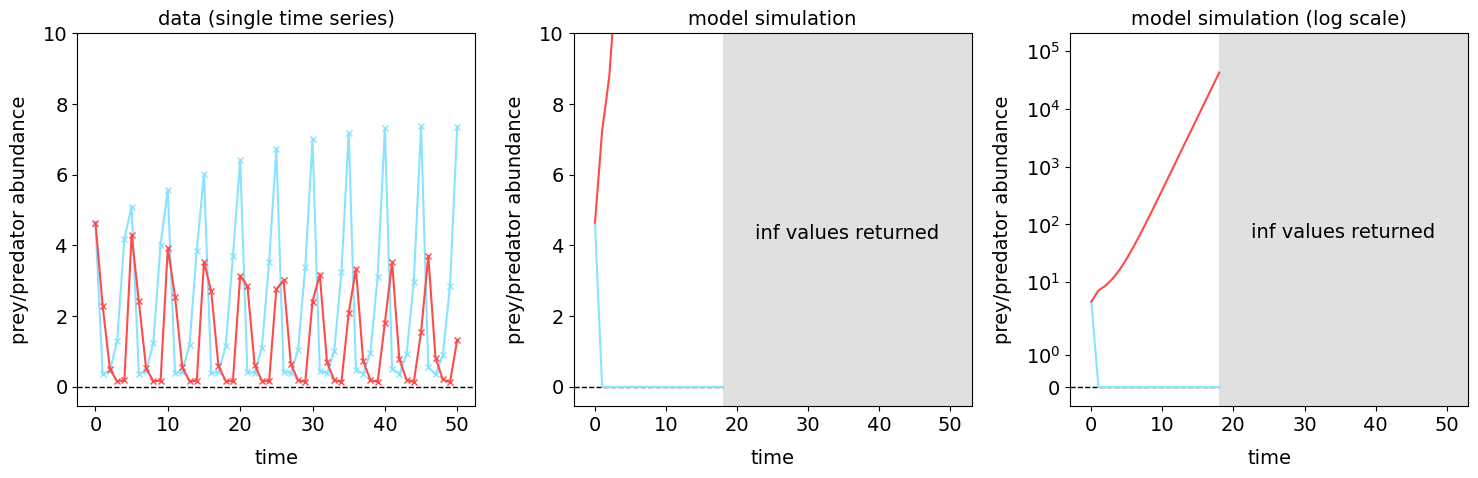

In [ ]:
from matplotlib.patches import Rectangle

rcParams["font.size"] = 14
rcParams['axes.labelpad'] = 10

model_no = 0
data_no = 2

deltas = idata.posterior.delta.sel(draw=model_no).values
last_step = np.sum(np.isnan(deltas[-1]))

problem = evaluator._solver.standalone_solver(models[model_no][-2-last_step], ts, ys[data_no,0], ())

fig, (ax_data,ax,ax2) = plt.subplots(ncols=3, figsize=(15,5))

ax_data.plot(ts, ys[data_no,:,0], "x-", markersize=5, c="#87E3FF", label="prey data")
ax_data.plot(ts, ys[data_no,:,1], "x-", markersize=5, c="#FF4A4A", label="predator data")
ax_data.axhline(0, linestyle="--", linewidth=1, color="black")
ax_data.set_xlabel("time", fontsize=14)
ax_data.set_ylabel("prey/predator abundance", fontsize=14)
ax_data.set_title("data (single time series)", fontsize=14)
ax_data.set(ylim=(-0.55,10))

ax.axhline(0, xmin=0, xmax=21/56, linestyle="--", linewidth=1, color="black")
ax.plot(ts, problem[0], c="#87E3FF", label="prey")
ax.plot(ts, problem[1], c="#FF4A4A", label="predator")
ax.add_patch(Rectangle((18,-0.7),35,11,facecolor="#E0E0E0"))
ax.yaxis.minorticks_off()
ax.set(xlim=(-3,53), ylim=(-0.55,10))
ax.set_xlabel("time", fontsize=14)
ax.set_ylabel("prey/predator abundance", fontsize=14)
ax.set_title("model simulation", fontsize=14)
ax.text(22.5,4.17,"inf values returned",rotation=0,size=14)

ax2.set_yscale("symlog")
ax2.axhline(0, xmax=21/56, linestyle="--", linewidth=1, color="black")
ax2.plot(ts, problem[0], c="#87E3FF", label="prey")
ax2.plot(ts, problem[1], c="#FF4A4A", label="predator")
ax2.add_patch(Rectangle((18,-0.6),35,200001,facecolor="#E0E0E0"))
ax2.set(xlim=(-3,53), ylim=(-0.6,200000))
ax2.set_xlabel("time", fontsize=14)
ax2.set_ylabel("prey/predator abundance", fontsize=14)
ax2.set_title("model simulation (log scale)", fontsize=14)
ax2.yaxis.minorticks_off()
ax2.text(22.5,58,"inf values returned",rotation=0,size=14)

# fig.suptitle("Lotka-Volterra UDE model successful training (with noise)")
fig.tight_layout()
fig.savefig("failed_training/close_to_zero_afterfailure.png")

### Model for Figure 11 (not close to zero)

#### Variant 1: Run inference process

In [4]:
class Func(UDEBase):

    mlp_depth: int = 3
    mlp_width: int = 3
    mlp_in_size: int = 2
    mlp_out_size: int = 2
    mlp_activation: Callable = staticmethod(jnn.softplus)
    mlp_final_activation: Callable = staticmethod(jnn.identity)

    alpha: jax.Array
    delta: jax.Array
    
    @staticmethod
    def model(t, y, mlp, alpha, delta, ):
        prey, predator = y
        
        dprey_dt_ode = alpha * prey 
        dpredator_dt_ode = - delta * predator
        dprey_dt_nn, dpredator_dt_nn = mlp(y) * jnp.array([jnp.tanh(prey).astype(float), jnp.tanh(predator).astype(float)])

        dprey_dt = dprey_dt_ode + dprey_dt_nn
        dpredator_dt = dpredator_dt_ode + dpredator_dt_nn

        return dprey_dt, dpredator_dt
    
    @staticmethod
    def loss(y_obs, y_pred):
        return (y_obs - y_pred)**2 + 0.001*(y_pred**-1)

Create a simulation with n=50 data batches

C:\Users\Markus\pymob\pymob\simulation.py:309: UserWarning: `sim.config.data_structure.prey = Datavariable(dimensions=['batch_id', 'time'] min=9.99999993922529e-09 max=28.933610916137695 observed=True dimensions_evaluator=None)` has been assumed from `sim.observations`. If the order of the dimensions should be different, specify `sim.config.data_structure.prey = DataVariable(dimensions=[...], ...)` manually.
  warnings.warn(
C:\Users\Markus\pymob\pymob\simulation.py:309: UserWarning: `sim.config.data_structure.predator = Datavariable(dimensions=['batch_id', 'time'] min=9.99999993922529e-09 max=28.875770568847656 observed=True dimensions_evaluator=None)` has been assumed from `sim.observations`. If the order of the dimensions should be different, specify `sim.config.data_structure.predator = DataVariable(dimensions=[...], ...)` manually.
  warnings.warn(
C:\Users\Markus\pymob\pymob\simulation.py:579: UserWarning: The number of ODE states was not specified in the config file [simulation]

MinMaxScaler(variable=prey, min=9.99999993922529e-09, max=28.933610916137695)
MinMaxScaler(variable=predator, min=9.99999993922529e-09, max=28.875770568847656)


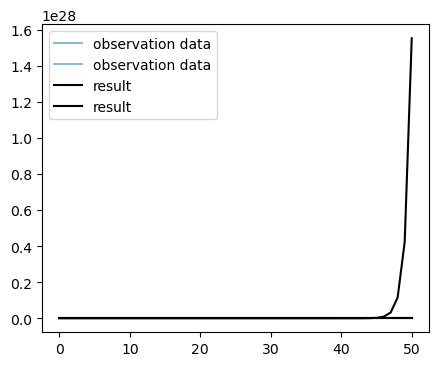

In [ ]:
n = 50

# Initialize the simulation object
sim = SimulationBase()

# Configure the case study
sim.config.case_study.name = "lotka_volterra_UDE_case_study"
sim.config.case_study.scenario = "UDETest"

key = jrandom.PRNGKey(5678)
data_key, model_key, optim_key = jrandom.split(key, 3)

# Add the model to the simulation
sim.model = Func({"alpha":jnp.array(1.3), "delta":jnp.array(1.8)},key=model_key)

# Define a solver
sim.solver = UDESolver

ts,ys = get_data(n, [1.3,0.9,0.8,1.8], 30, 1, 50, 51, 0.0, key=jr.PRNGKey(0))

# Create an xArray dataset containing the artificial data
datasets = jnp.linspace(0,n-1,n)

test_data1 = xr.DataArray(ys[:,:,0], coords={"batch_id": datasets, "time": ts}).to_dataset(name="prey")
test_data2 = xr.DataArray(ys[:,:,1], coords={"batch_id": datasets, "time": ts}).to_dataset(name="predator")
test_data = xr.merge([test_data1, test_data2])

# Add our dataset to the simulation
sim.observations = test_data

# Add the initial condition to the simulation
sim.model_parameters["y0"] = sim.observations.sel(time = 0).drop_vars("time")

sim.config.model_parameters.alpha = Param(value=1.3, free=False)
sim.config.model_parameters.delta = Param(value=1.8, free=True)
sim.config.model_parameters.delta.prior = "uniform(loc=1.0,scale=2.0)"

sim.model_parameters["parameters"] = sim.config.model_parameters.value_dict

# Create an xArray dataset containing the external input data
# xin = xr.DataArray(np.zeros(201), coords={"time": ts}).to_dataset(name="x_in")

# Add external inputs to the simulation
# sim.model_parameters["x_in"] = xin

# sim.config.jaxsolver.max_steps = 10000
sim.config.jaxsolver.throw_exception = False

# Put everything in place for running the simulation
sim.dispatch_constructor()

# Create an evaluator
evaluator = sim.dispatch()

Initialize inferer

In [6]:
sim.config.inference_optax.MLP_weight_dist = "normal()"
sim.config.inference_optax.MLP_bias_dist = "normal()"
sim.config.inference_optax.batch_size = 20
sim.config.inference_optax.data_split = 0.8
sim.config.inference_optax.multiple_runs_target = 10
sim.config.inference_optax.multiple_runs_limit = 20
sim.config.inference_optax.time_limit = 600

sim.config.inference_optax.length_strategy = [0.1,1]
sim.config.inference_optax.lr_strategy = 0.01
sim.config.inference_optax.steps_strategy = [1000, 1000]
sim.config.inference_optax.clip_strategy = 0.1
sim.config.inference_optax.indepth = "off"

sim.set_inferer("optax")

# grad_loss_debug(model, ts, ys, 5, x_in, loss_func)
# self.simulation.evaluator._solver.standalone_solver(model, ts, ys[0,0], x_in)

Runs inferer (implementation using the `standalone_solver` workaround)

In [66]:
sim.inferer.run(optim_key)

10 of 10 runs completed: 100%|██████████| 20000/20000 [25:45<00:00, 12.94it/s, 6 unsuccessful runs so far]  



run number	successful?	loss

run 1		yes		13.00648021697998
run 2		no		---
run 3		yes		13.150424003601074
run 4		yes		12.914373397827148
run 5		yes		13.316783905029297
run 6		no		---
run 7		yes		13.087770462036133
run 8		no		---
run 9		no		---
run 10		yes		13.348457336425781
run 11		yes		13.218241691589355
run 12		no		---
run 13		yes		12.992547988891602
run 14		yes		12.963461875915527
run 15		no		---
run 16		yes		12.903007507324219


Save results

In [82]:
sim.inferer.store_results("failed_training/not_close_to_zero.nc", "failed_training/not_close_to_zero_f.nc")

Among the ten models, plot the one that looks most similar to the data

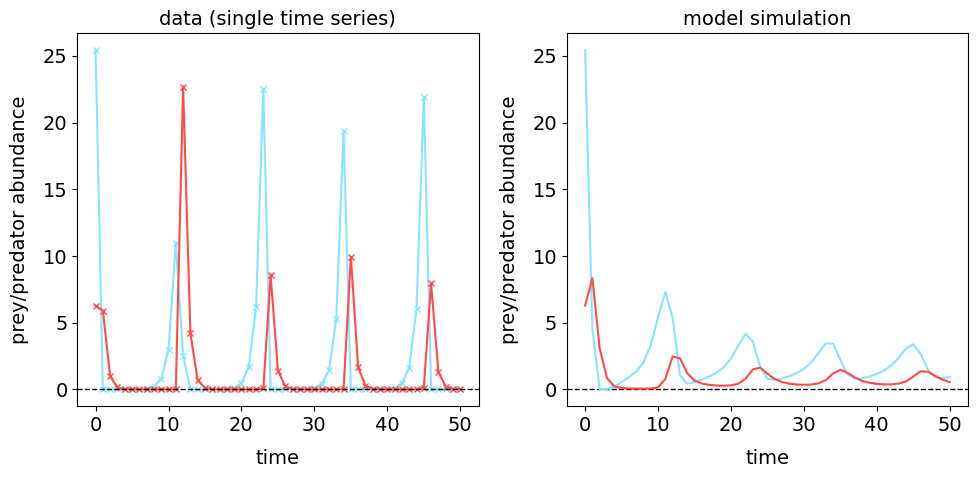

In [81]:
rcParams["font.size"] = 14
rcParams['axes.labelpad'] = 10

model_no = 8
data_no = 0

problem = evaluator._solver.standalone_solver(sim.inferer.optimized_models[model_no], ts, ys[data_no,0], ())

fig, (ax_data,ax) = plt.subplots(ncols=2, figsize=(10,5))

ax_data.plot(ts, ys[data_no,:,0], "x-", markersize=5, c="#87E3FF", label="prey data")
ax_data.plot(ts, ys[data_no,:,1], "x-", markersize=5, c="#FF4A4A", label="predator data")
ax_data.axhline(0, linestyle="--", linewidth=1, color="black")
ax_data.set_xlabel("time", fontsize=14)
ax_data.set_ylabel("prey/predator abundance", fontsize=14)
ax_data.set_title("data (single time series)", fontsize=14)

ax.axhline(0, xmin=0, xmax=1, linestyle="--", linewidth=1, color="black")
ax.plot(ts, problem[0], c="#87E3FF", label="prey")
ax.plot(ts, problem[1], c="#FF4A4A", label="predator")
ax.yaxis.minorticks_off()
ax.set_xlabel("time", fontsize=14)
ax.set_ylabel("prey/predator abundance", fontsize=14)
ax.set_title("model simulation", fontsize=14)

fig.tight_layout()
fig.savefig("failed_training/not_close_to_zero.png")

#### Variant 2: Load data

Model formulation

In [3]:
class Func(UDEBase):

    mlp_depth: int = 3
    mlp_width: int = 3
    mlp_in_size: int = 2
    mlp_out_size: int = 2
    mlp_activation: Callable = staticmethod(jnn.softplus)
    mlp_final_activation: Callable = staticmethod(jnn.identity)

    alpha: jax.Array
    delta: jax.Array
    
    @staticmethod
    def model(t, y, mlp, alpha, delta, ):
        prey, predator = y
        
        dprey_dt_ode = alpha * prey 
        dpredator_dt_ode = - delta * predator
        dprey_dt_nn, dpredator_dt_nn = mlp(y) * jnp.array([jnp.tanh(prey).astype(float), jnp.tanh(predator).astype(float)])

        dprey_dt = dprey_dt_ode + dprey_dt_nn
        dpredator_dt = dpredator_dt_ode + dpredator_dt_nn

        return dprey_dt, dpredator_dt
    
    @staticmethod
    def loss(y_obs, y_pred):
        return (y_obs - y_pred)**2 + 0.001*(y_pred**-1)

Create models from data

In [4]:
idata = az.from_netcdf("failed_training/not_close_to_zero.nc")

model_key = jr.PRNGKey(0)
models = [Func({"alpha":jnp.array(1.3), "delta":idata.posterior.sel(draw=i).delta.values[0]},weights=idata.posterior.sel(draw=i).weights.values.tolist()[0],bias=idata.posterior.sel(draw=i).bias.values.tolist()[0],key=model_key) for i in np.arange(0, 10)]

Create SimulationBase, observation data, and Evaluator

In [ ]:
n = 50

# Initialize the simulation object
sim = SimulationBase()

# Configure the case study
sim.config.case_study.name = "lotka_volterra_UDE_case_study"
sim.config.case_study.scenario = "UDETest"

key = jrandom.PRNGKey(5678)
data_key, model_key, optim_key = jrandom.split(key, 3)

# Add the model to the simulation
sim.model = Func({"alpha":jnp.array(1.3), "delta":jnp.array(1.8)},key=model_key)

# Define a solver
sim.solver = UDESolver

ts,ys = get_data(n, [1.3,0.9,0.8,1.8], 30, 1, 50, 51, 0.0, key=jr.PRNGKey(0))

# Create an xArray dataset containing the artificial data
datasets = jnp.linspace(0,n-1,n)

test_data1 = xr.DataArray(ys[:,:,0], coords={"batch_id": datasets, "time": ts}).to_dataset(name="prey")
test_data2 = xr.DataArray(ys[:,:,1], coords={"batch_id": datasets, "time": ts}).to_dataset(name="predator")
test_data = xr.merge([test_data1, test_data2])

# Add our dataset to the simulation
sim.observations = test_data

# Add the initial condition to the simulation
sim.model_parameters["y0"] = sim.observations.sel(time = 0).drop_vars("time")

sim.config.model_parameters.alpha = Param(value=1.3, free=False)
sim.config.model_parameters.delta = Param(value=1.8, free=True)
sim.config.model_parameters.delta.prior = "uniform(loc=1.0,scale=2.0)"

sim.model_parameters["parameters"] = sim.config.model_parameters.value_dict

# Create an xArray dataset containing the external input data
# xin = xr.DataArray(np.zeros(201), coords={"time": ts}).to_dataset(name="x_in")

# Add external inputs to the simulation
# sim.model_parameters["x_in"] = xin

# sim.config.jaxsolver.max_steps = 10000
sim.config.jaxsolver.throw_exception = False

# Put everything in place for running the simulation
sim.dispatch_constructor()

# Create an evaluator
evaluator = sim.dispatch()

MinMaxScaler(variable=prey, min=9.99999993922529e-09, max=28.933610916137695)
MinMaxScaler(variable=predator, min=9.99999993922529e-09, max=28.875770568847656)


C:\Users\Markus\pymob\pymob\simulation.py:309: UserWarning: `sim.config.data_structure.prey = Datavariable(dimensions=['batch_id', 'time'] min=9.99999993922529e-09 max=28.933610916137695 observed=True dimensions_evaluator=None)` has been assumed from `sim.observations`. If the order of the dimensions should be different, specify `sim.config.data_structure.prey = DataVariable(dimensions=[...], ...)` manually.
  warnings.warn(
C:\Users\Markus\pymob\pymob\simulation.py:309: UserWarning: `sim.config.data_structure.predator = Datavariable(dimensions=['batch_id', 'time'] min=9.99999993922529e-09 max=28.875770568847656 observed=True dimensions_evaluator=None)` has been assumed from `sim.observations`. If the order of the dimensions should be different, specify `sim.config.data_structure.predator = DataVariable(dimensions=[...], ...)` manually.
  warnings.warn(
C:\Users\Markus\pymob\pymob\simulation.py:579: UserWarning: The number of ODE states was not specified in the config file [simulation]

Among the ten models, plot the one that looks most similar to the data

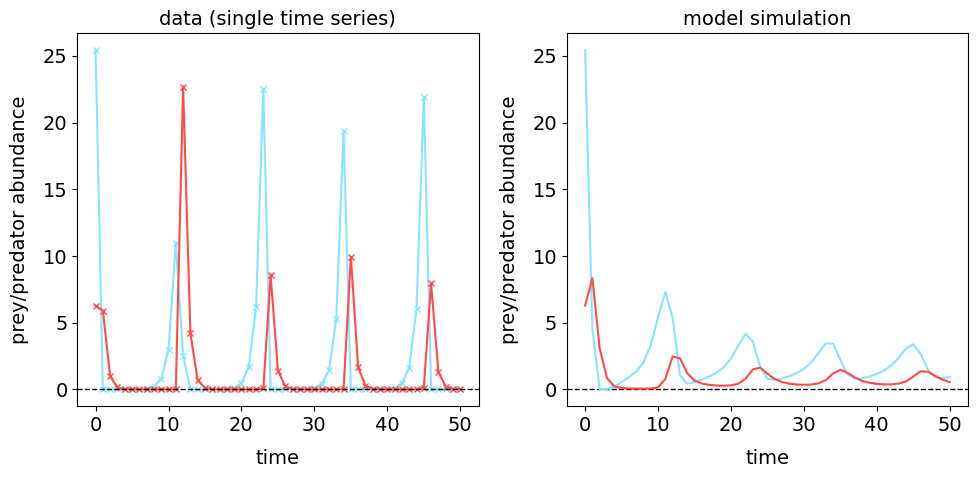

In [ ]:
rcParams["font.size"] = 14
rcParams['axes.labelpad'] = 10

model_no = 8
data_no = 0

problem = evaluator._solver.standalone_solver(models[model_no], ts, ys[data_no,0], ())

fig, (ax_data,ax) = plt.subplots(ncols=2, figsize=(10,5))

ax_data.plot(ts, ys[data_no,:,0], "x-", markersize=5, c="#87E3FF", label="prey data")
ax_data.plot(ts, ys[data_no,:,1], "x-", markersize=5, c="#FF4A4A", label="predator data")
ax_data.axhline(0, linestyle="--", linewidth=1, color="black")
ax_data.set_xlabel("time", fontsize=14)
ax_data.set_ylabel("prey/predator abundance", fontsize=14)
ax_data.set_title("data (single time series)", fontsize=14)

ax.axhline(0, xmin=0, xmax=1, linestyle="--", linewidth=1, color="black")
ax.plot(ts, problem[0], c="#87E3FF", label="prey")
ax.plot(ts, problem[1], c="#FF4A4A", label="predator")
ax.yaxis.minorticks_off()
ax.set_xlabel("time", fontsize=14)
ax.set_ylabel("prey/predator abundance", fontsize=14)
ax.set_title("model simulation", fontsize=14)

fig.tight_layout()
fig.savefig("failed_training/not_close_to_zero.png")

### Model for Figures 12 and 13 (noisy initial conditions)

In [ ]:
import arviz as az

idata = az.from_netcdf(f"hyperparams/scenario_51_0.5_hyperparams_(0.1, 0.2, 0.5, 1.0)_0.01_0.0_20/optax_idata.nc")

model_key = jr.PRNGKey(0)

models = [Func({"alpha":jnp.array(1.3), "delta":idata.posterior.sel(draw=i).delta.values[0]},weights=idata.posterior.sel(draw=i).weights.values.tolist()[0],bias=idata.posterior.sel(draw=i).bias.values.tolist()[0],key=model_key) for i in np.arange(0, 10)]

In [85]:
# Initialize the simulation object
sim = SimulationBase()

# Configure the case study
sim.config.case_study.name = "lotka_volterra_UDE_case_study"
sim.config.case_study.scenario = "UDETest"

# Add the model to the simulation
key = jrandom.PRNGKey(5678)
data_key, model_key, loader_key = jrandom.split(key, 3)
sim.model = models[0]
# Define a solver
sim.solver = UDESolver

# Add our dataset to the simulation
sim.observations = idata.observed_data

# Add the initial condition to the simulation
sim.model_parameters["y0"] = sim.observations.sel(time = 0).drop_vars("time")

sim.config.model_parameters.alpha = Param(value=1.3, free=False)
sim.config.model_parameters.delta = Param(value=1.8, free=True)
sim.config.model_parameters.delta.prior = "uniform(loc=1.0,scale=2.0)"

sim.model_parameters["parameters"] = sim.config.model_parameters.value_dict

sim.config.jaxsolver.max_steps = 10000
sim.config.jaxsolver.throw_exception = False

sim.coordinates["time"] = np.linspace(0,50,1001)

# Put everything in place for running the simulation
sim.dispatch_constructor()

# Create an evaluator, run the simulation and obtain the results
evaluator = sim.dispatch()

# ys = jnp.stack(jnp.array([idata.observed_data.prey.values, idata.observed_data.predator.values]), axis=2)
# ts = jnp.linspace(0, 50, ys.shape[1])

ts, ys = get_data(50, [1.3, 0.9, 0.8, 1.8], 5, 1, 50, 51, 0.5, key=jr.PRNGKey(0))
ts_highres, ys_highres = get_data(50, [1.3, 0.9, 0.8, 1.8], 5, 1, 50, 1001, 0, key=jr.PRNGKey(0))

res = [[evaluator._solver.standalone_solver(model, ts_highres, y[0], ()) for y in ys] for model in models]

C:\Users\Markus\pymob\pymob\simulation.py:309: UserWarning: `sim.config.data_structure.prey = Datavariable(dimensions=['batch_id', 'time'] min=1e-08 max=7.675207899883114 observed=True dimensions_evaluator=None)` has been assumed from `sim.observations`. If the order of the dimensions should be different, specify `sim.config.data_structure.prey = DataVariable(dimensions=[...], ...)` manually.
  warnings.warn(
C:\Users\Markus\pymob\pymob\simulation.py:309: UserWarning: `sim.config.data_structure.predator = Datavariable(dimensions=['batch_id', 'time'] min=1e-08 max=5.7145672229795155 observed=True dimensions_evaluator=None)` has been assumed from `sim.observations`. If the order of the dimensions should be different, specify `sim.config.data_structure.predator = DataVariable(dimensions=[...], ...)` manually.
  warnings.warn(
C:\Users\Markus\pymob\pymob\simulation.py:579: UserWarning: The number of ODE states was not specified in the config file [simulation] > 'n_ode_states = <n>'. Extrac

MinMaxScaler(variable=prey, min=1e-08, max=7.675207899883114)
MinMaxScaler(variable=predator, min=1e-08, max=5.7145672229795155)


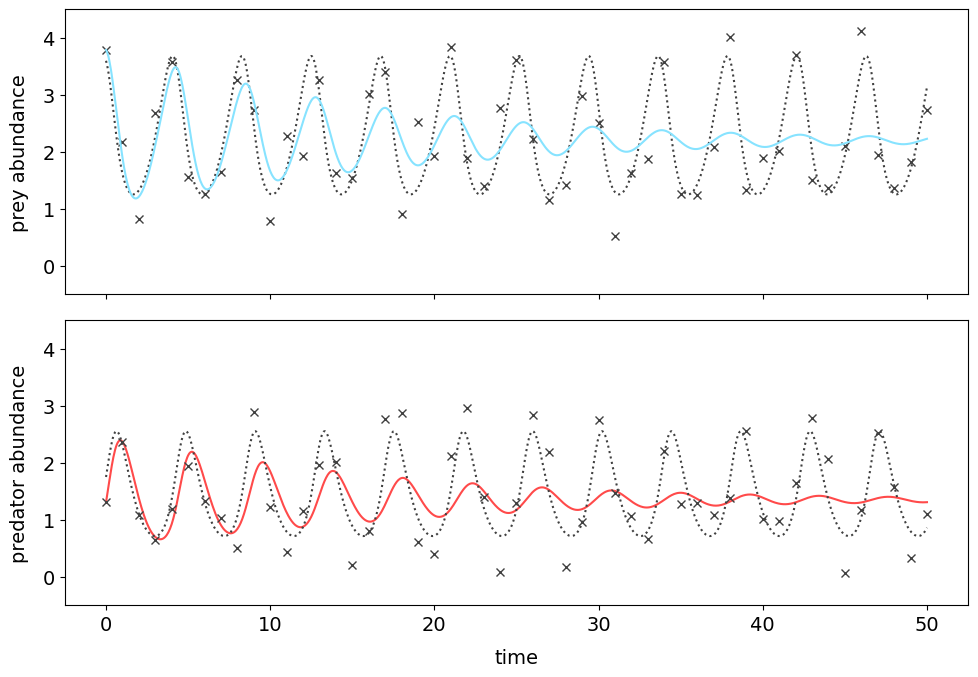

In [87]:
rcParams["font.size"] = 14
rcParams["axes.labelpad"] = 10

model_number = 9 # best model
time_series = 26

fig, (ax_prey, ax_predator) = plt.subplots(nrows = 2, figsize = (10,7), sharex=True)

ax_prey.plot(ts_highres, jnp.stack(ys_highres[time_series], axis=1)[0], ":", c="#404040", zorder=9)
ax_predator.plot(ts_highres, jnp.stack(ys_highres[time_series], axis=1)[1], ":", c="#404040", zorder=9)
ax_prey.plot(ts, ys[time_series,:,0], "x", c="#404040", zorder=9)
ax_predator.plot(ts, ys[time_series,:,1], "x", c="#404040", zorder=9)

ax_prey.plot(ts_highres, res[model_number][time_series][0], c="#87E3FF", zorder=10)
ax_predator.plot(ts_highres, res[model_number][time_series][1], c="#FF4A4A")

ax_prey.set_ylim((-0.5,4.5))
ax_prey.set_ylabel("prey abundance", fontsize=14)
ax_predator.set_ylim((-0.5,4.5))
ax_predator.set_xlabel("time", fontsize=14)
ax_predator.set_ylabel("predator abundance", fontsize=14)

fig.tight_layout()
fig.savefig("failed_training/noisy_initial_condition.png")

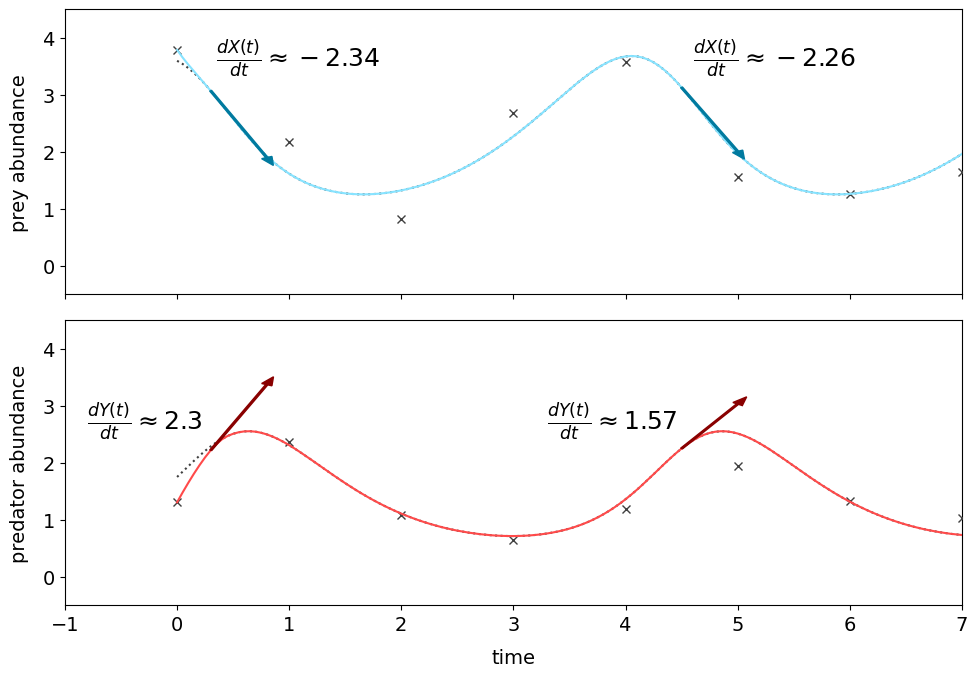

In [ ]:
rcParams["font.size"] = 14
rcParams["axes.labelpad"] = 10

model_number = 9 # best model
time_series = 26

t_converge = 10

weight = jnp.linspace(0, 1, t_converge)
weights = jnp.concatenate([jnp.expand_dims(weight,1), jnp.expand_dims(weight,1)], axis=1)

ys_fiction = jnp.concatenate([(1- weights) * jnp.stack([jnp.linspace(ys[time_series,0,0], ys_highres[time_series,t_converge-1,0], t_converge), jnp.linspace(ys[time_series,0,1], ys_highres[time_series,t_converge-1,1], t_converge)], axis=1) + weights * ys_highres[time_series,0:t_converge], ys_highres[time_series,t_converge:]])

fig, (ax_prey, ax_predator) = plt.subplots(nrows = 2, figsize = (10,7), sharex=True)

ax_prey.plot(ts_highres, jnp.stack(ys_highres[time_series], axis=1)[0], ":", c="#404040", zorder=9)
ax_predator.plot(ts_highres, jnp.stack(ys_highres[time_series], axis=1)[1], ":", c="#404040", zorder=9)
ax_prey.plot(ts, ys[time_series,:,0], "x", c="#404040", zorder=9)
ax_predator.plot(ts, ys[time_series,:,1], "x", c="#404040", zorder=9)

ax_prey.plot(ts_highres, ys_fiction[:,0], c="#87E3FF", zorder=10)
ax_predator.plot(ts_highres, ys_fiction[:,1], c="#FF4A4A", zorder=10)

ax_prey.set_xlim((-1, 10))
ax_prey.set_ylim((-0.5,4.5))
ax_prey.set_ylabel("prey abundance", fontsize=14)
ax_predator.set_xlim((-1, 7))
ax_predator.set_ylim((-0.5,4.5))
ax_predator.set_xlabel("time", fontsize=14)
ax_predator.set_ylabel("predator abundance", fontsize=14)

ax_prey.arrow(0.3,ys_fiction[6][0],0.5,-1.17,zorder=12,head_width=0.1,color="#007A9F",width=0.02)
ax_prey.arrow(4.5,ys_fiction[90][0],0.5,-1.12,zorder=12,head_width=0.1,color="#007A9F",width=0.02)
ax_predator.arrow(0.3,ys_fiction[6][1],0.5, 1.15,zorder=12,head_width=0.1,color="#890000",width=0.02)
ax_predator.arrow(4.5,ys_fiction[90][1],0.5,0.78,zorder=12,head_width=0.1,color="#890000",width=0.02)

ax_prey.text(0.35,3.5,"$\\frac{dX(t)}{dt} \\approx -2.34$",rotation=0,size=18)
ax_prey.text(4.6,3.5,"$\\frac{dX(t)}{dt} \\approx -2.26$",rotation=0,size=18)
ax_predator.text(-0.8,2.6,"$\\frac{dY(t)}{dt} \\approx 2.3$",rotation=0,size=18)
ax_predator.text(3.3,2.6,"$\\frac{dY(t)}{dt} \\approx 1.57$",rotation=0,size=18)

fig.tight_layout()
fig.savefig("failed_training/noisy_initial_condition2.png")